# AI 주식 예측
- M7 종가 예측 ML/DL 모델
- 회귀 테스크
- yfinance(야후 파이낸셜) 라이브러리 사용

## Baseline

In [118]:
import os

import joblib
import numpy as np
import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

SEED = 42

sns.set_palette("rocket")
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [119]:
os.makedirs("dataset", exist_ok=True)

tickers = [
    "AAPL",
    "MSFT",
    "NVDA",
    "AMZN",
    "GOOGL",
    "META",
    "TSLA"
]

all_df = []

for ticker in tickers:
    df = yf.download(
        ticker,
        start="2016-07-01",
        end="2026-07-01",
        progress=False
    )

    # MultiIndex 제거
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df.reset_index()
    df["Ticker"] = ticker

    all_df.append(df)

stock_df = pd.concat(all_df, ignore_index=True)

# 컬럼 순서 정리
stock_df = stock_df[[
    "Date",
    "Ticker",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]]

# 저장
stock_df.to_csv("dataset/stock_data.csv", index=False, encoding="utf-8-sig")

print(stock_df.shape)
stock_df.head()

(17584, 7)


Price,Date,Ticker,Open,High,Low,Close,Volume
0,2016-07-01,AAPL,21.738265,21.961362,21.701841,21.829325,104106000
1,2016-07-05,AAPL,21.715498,21.717775,21.503783,21.624437,110820800
2,2016-07-06,AAPL,21.535657,21.776967,21.483299,21.747372,123796400
3,2016-07-07,AAPL,21.786067,21.968187,21.767856,21.840704,100558400
4,2016-07-08,AAPL,21.965913,22.056973,21.865748,22.009167,115648400


| 컬럼명 | 데이터 타입 | 설명 | 예시 |
|--------|------------|------|------|
| **Date** | datetime | 주식 거래가 이루어진 날짜 | 2024-01-02 |
| **Ticker** | string | 종목을 구분하는 주식 티커(Symbol) | AAPL, MSFT, NVDA |
| **Open** | float | 해당 거래일의 시가(장 시작 가격) | 185.24 |
| **High** | float | 해당 거래일의 최고 거래 가격 | 187.85 |
| **Low** | float | 해당 거래일의 최저 거래 가격 | 184.91 |
| **Close** | float | 해당 거래일의 종가(장 마감 가격) | 186.73 |
| **Volume** | int | 해당 거래일 동안 거래된 주식 수(거래량) | 53,412,800 |

In [120]:
origin_df = stock_df.copy()

In [121]:
stock_df.describe()

Price,Date,Open,High,Low,Close,Volume
count,17584,17584.000000,17584.000000,17584.000000,17584.000000,1.758400e+04
mean,2021-06-28 13:20:15,161.337544,163.433872,159.175347,161.359713,1.159550e+08
min,2016-07-01 00:00:00,1.137501,1.161036,1.128431,1.143876,4.726100e+06
25%,2018-12-30 06:00:00,51.668020,52.218252,51.083066,51.625755,2.645800e+07
50%,2021-06-28 12:00:00,136.406042,138.372463,134.832422,136.434235,5.284275e+07
75%,2023-12-26 06:00:00,221.248763,224.010179,217.887505,220.945450,1.124368e+08
max,2026-06-30 00:00:00,788.565460,793.648814,778.269228,787.419189,3.692928e+09
std,NaN,139.058487,140.781311,137.190011,138.999178,1.749854e+08


In [122]:
stock_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17584 entries, 0 to 17583
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    17584 non-null  datetime64[s]
 1   Ticker  17584 non-null  str          
 2   Open    17584 non-null  float64      
 3   High    17584 non-null  float64      
 4   Low     17584 non-null  float64      
 5   Close   17584 non-null  float64      
 6   Volume  17584 non-null  int64        
dtypes: datetime64[s](1), float64(4), int64(1), str(1)
memory usage: 961.8 KB


In [123]:
stock_df.isna().sum()

Price
Date      0
Ticker    0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [124]:
stock_df['Date'] = pd.to_datetime(stock_df['Date'])
stock_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17584 entries, 0 to 17583
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    17584 non-null  datetime64[s]
 1   Ticker  17584 non-null  str          
 2   Open    17584 non-null  float64      
 3   High    17584 non-null  float64      
 4   Low     17584 non-null  float64      
 5   Close   17584 non-null  float64      
 6   Volume  17584 non-null  int64        
dtypes: datetime64[s](1), float64(4), int64(1), str(1)
memory usage: 961.8 KB


In [125]:
stock_df = stock_df.sort_values(
    ['Ticker', 'Date']
).reset_index(drop=True)

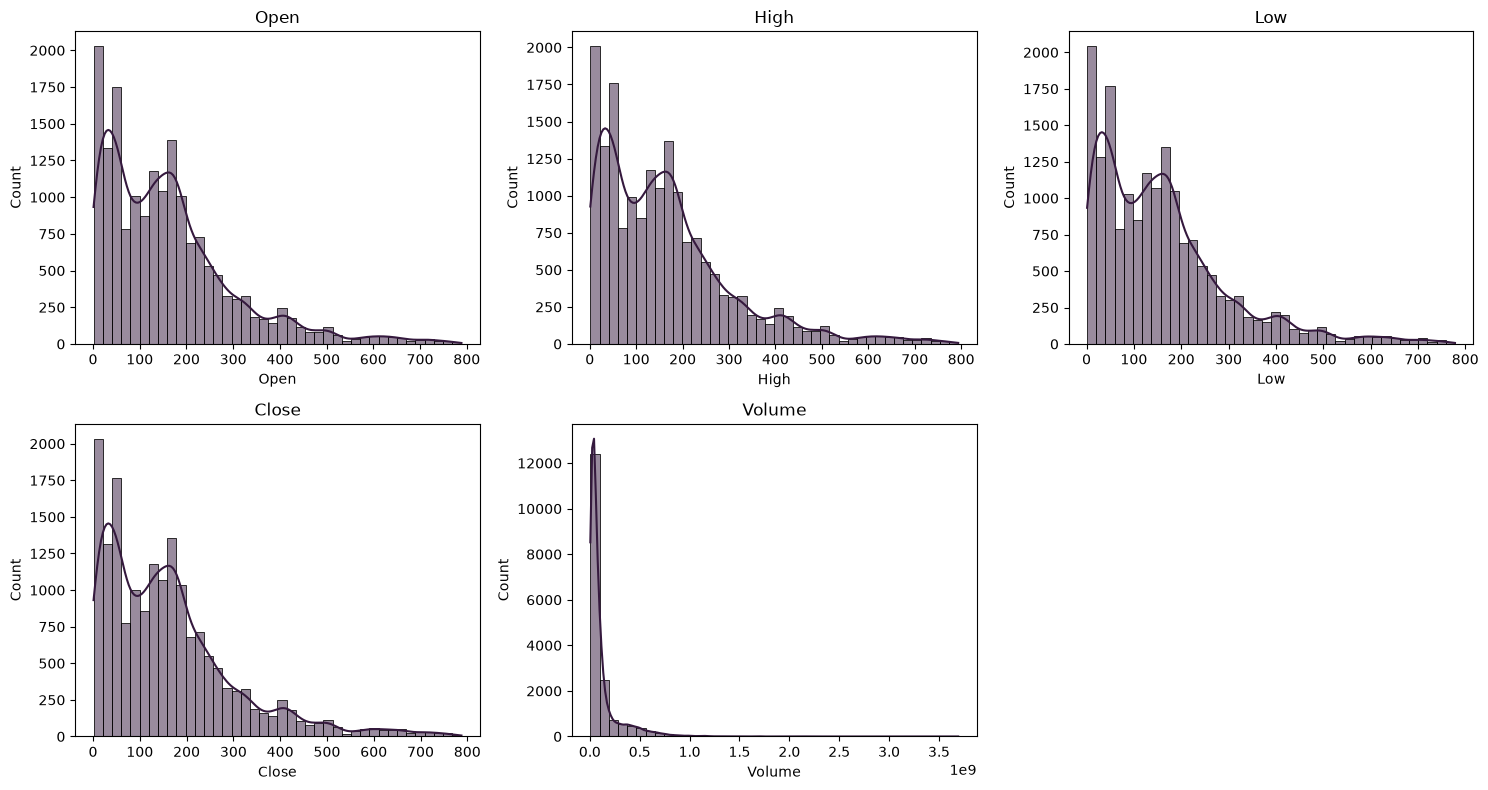

In [126]:
numeric_cols = [
    'Open',
    'High',
    'Low',
    'Close',
    'Volume'
]

plt.figure(figsize=(15, 8))

for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(stock_df[col], bins=40, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

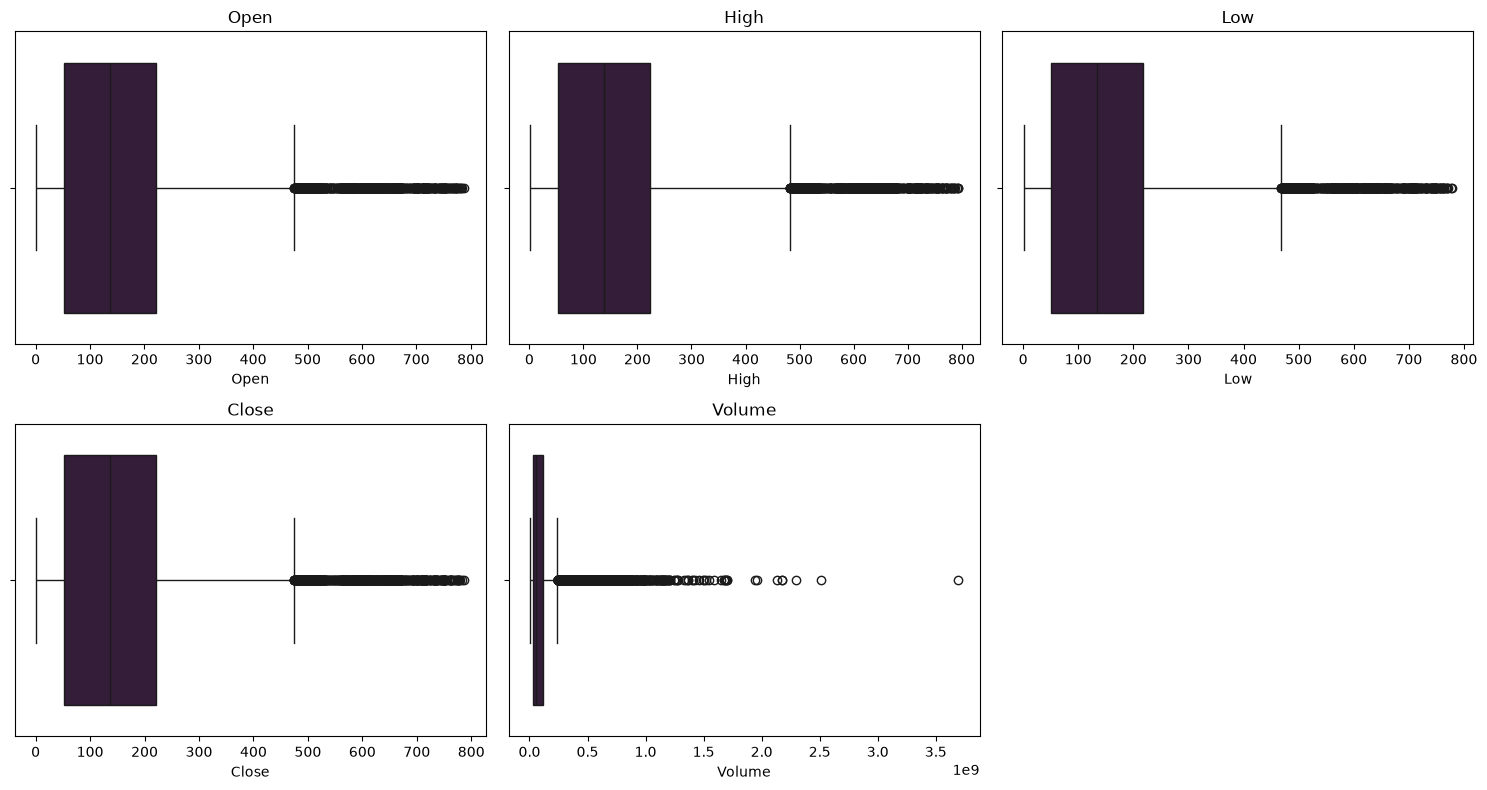

In [127]:
plt.figure(figsize=(15, 8))

for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x=stock_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

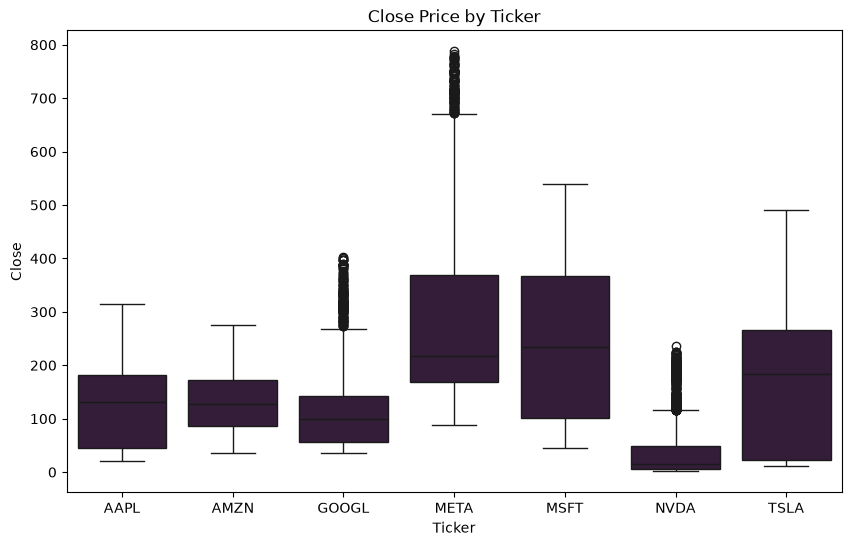

In [128]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=stock_df,
    x='Ticker',
    y='Close'
)

plt.title('Close Price by Ticker')
plt.show()

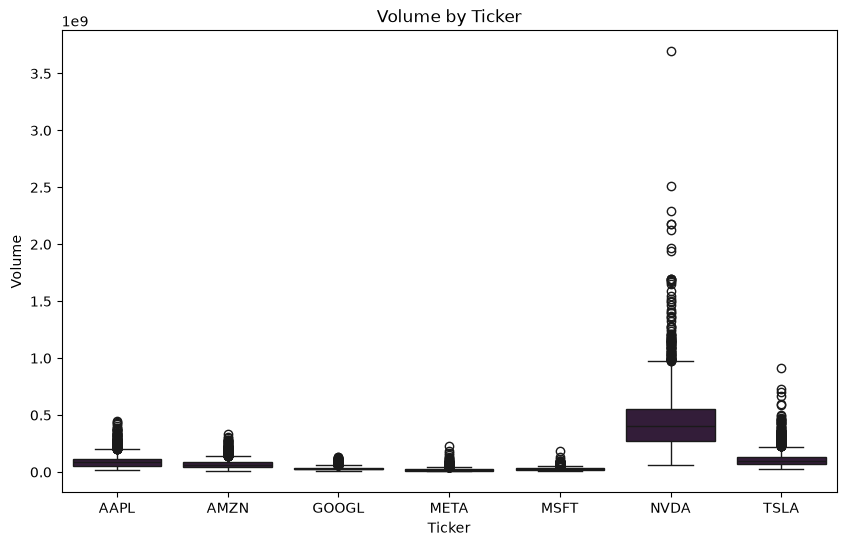

In [129]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=stock_df,
    x='Ticker',
    y='Volume'
)

plt.title('Volume by Ticker')
plt.show()

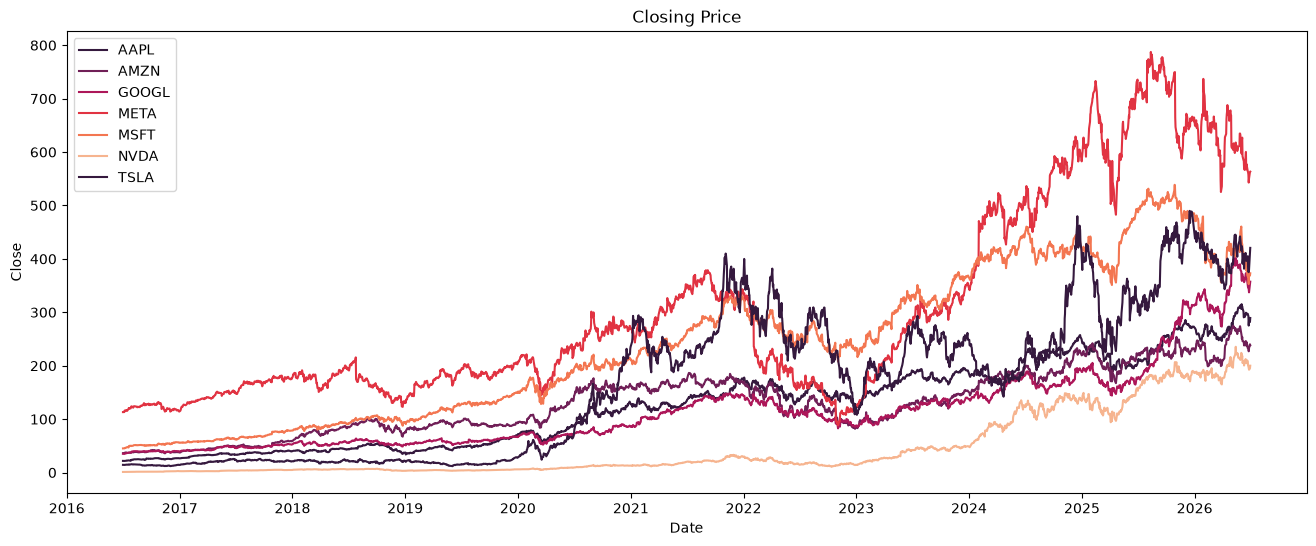

In [130]:
plt.figure(figsize=(16, 6))

for ticker in stock_df['Ticker'].unique():
    temp = stock_df[stock_df['Ticker'] == ticker]
    
    plt.plot(
        temp['Date'],
        temp['Close'],
        label=ticker
    )

plt.legend()
plt.title('Closing Price')
plt.xlabel('Date')
plt.ylabel('Close')
plt.show()

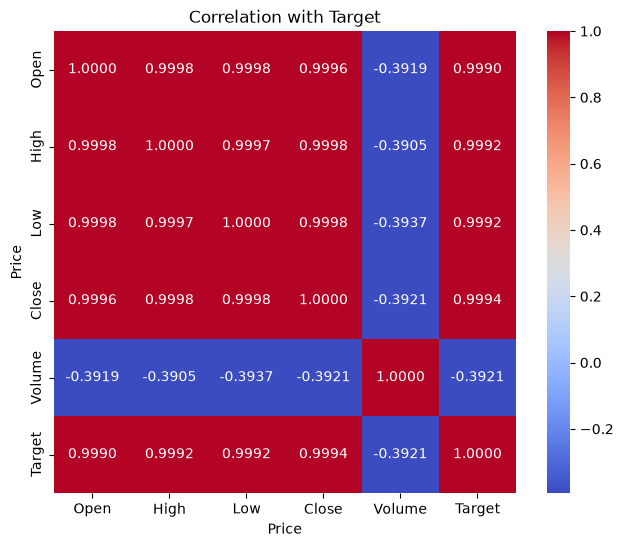

In [131]:
stock_df['Target'] = (stock_df.groupby('Ticker')['Close'].shift(-1))

corr = stock_df[[
    'Open',
    'High',
    'Low',
    'Close',
    'Volume',
    'Target'
]].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt='.4f',
    cmap='coolwarm',
    square=True
)

plt.title('Correlation with Target')
plt.show()

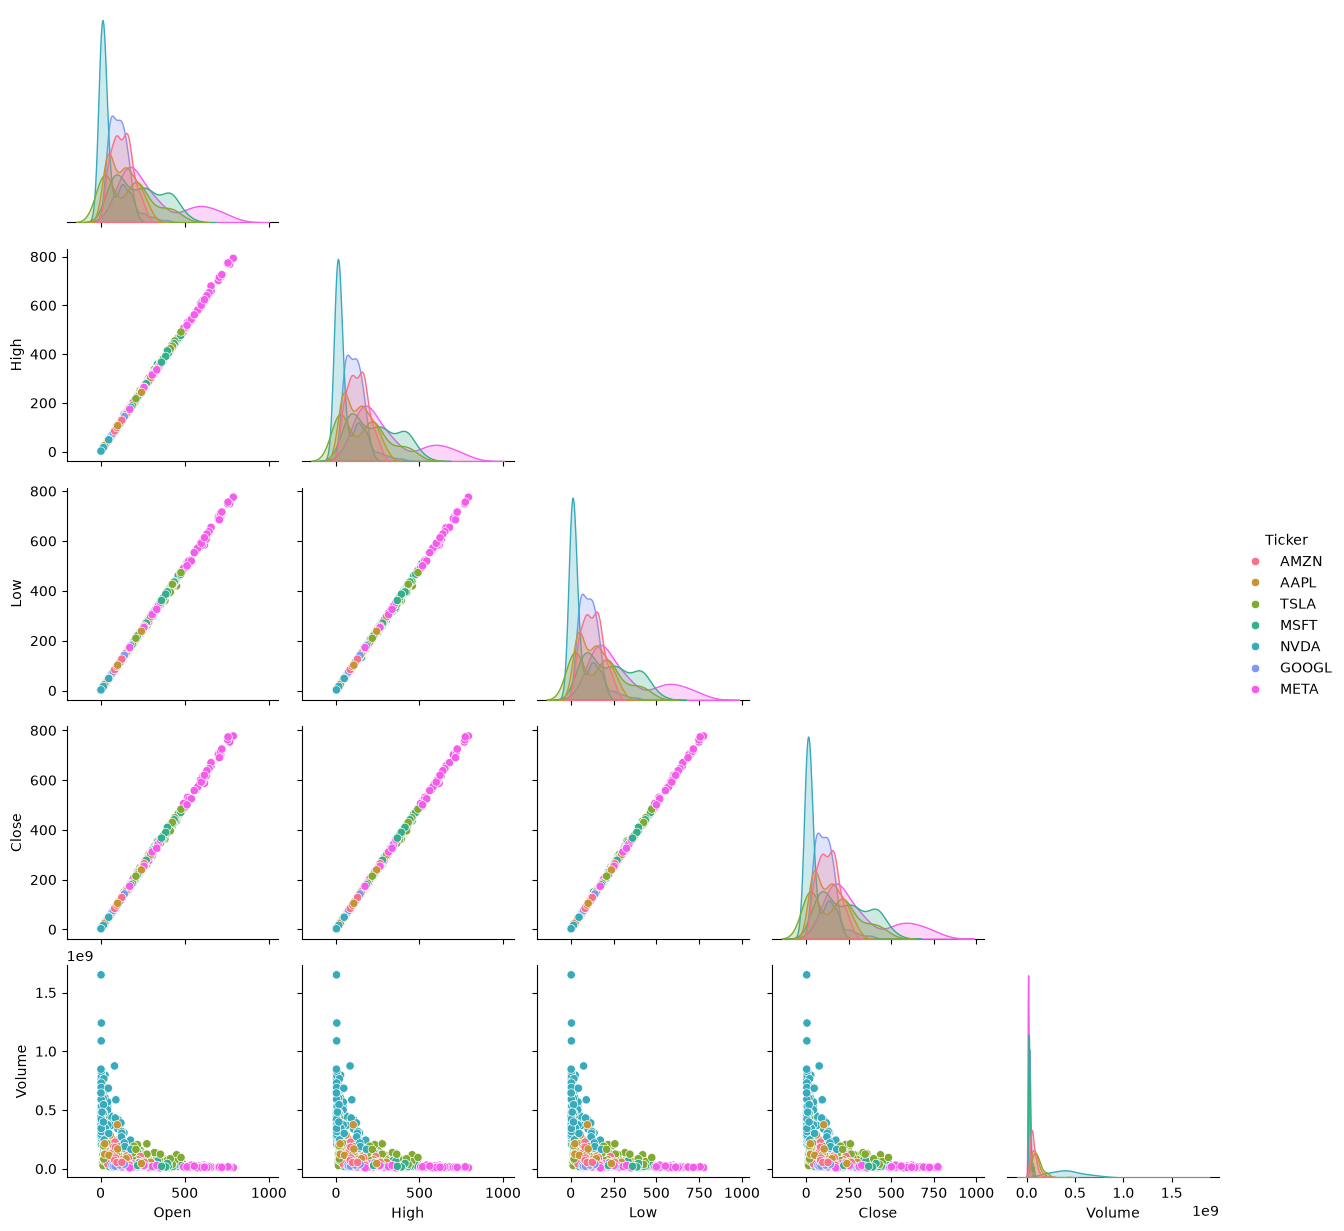

In [132]:
sample_df = stock_df.sample(1000, random_state=SEED)

sns.pairplot(
    sample_df,
    vars=[
        'Open',
        'High',
        'Low',
        'Close',
        'Volume'
    ],
    hue='Ticker',
    corner=True
)

plt.show()

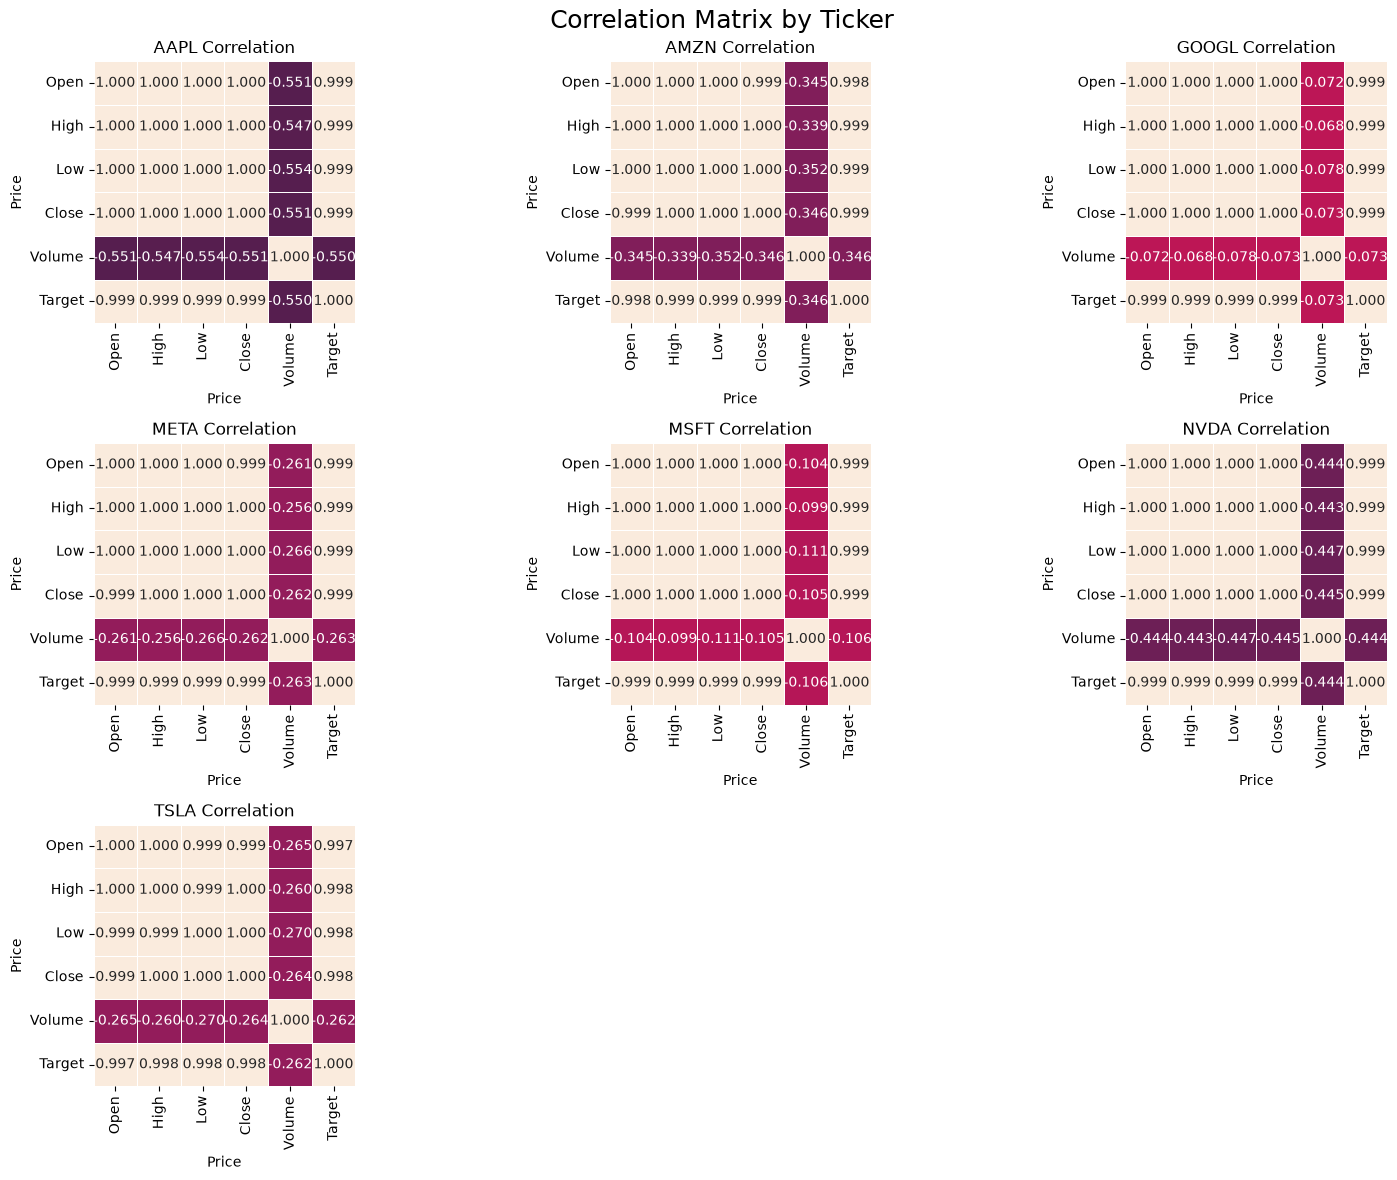

In [133]:
tickers = stock_df["Ticker"].unique()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    temp = stock_df[
        stock_df["Ticker"] == ticker
    ]

    corr = temp[[
        "Open",
        "High",
        "Low",
        "Close",
        "Volume",
        "Target"
    ]].corr()

    sns.heatmap(
        corr,
        annot=True,
        fmt=".3f",
        cmap="rocket",
        square=True,
        linewidths=0.5,
        ax=axes[i],
        cbar=False,
        vmin=-1,
        vmax=1
    )

    axes[i].set_title(f"{ticker} Correlation")

# 사용하지 않는 subplot 제거
for j in range(len(tickers), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Correlation Matrix by Ticker", fontsize=18)
plt.tight_layout()
plt.show()

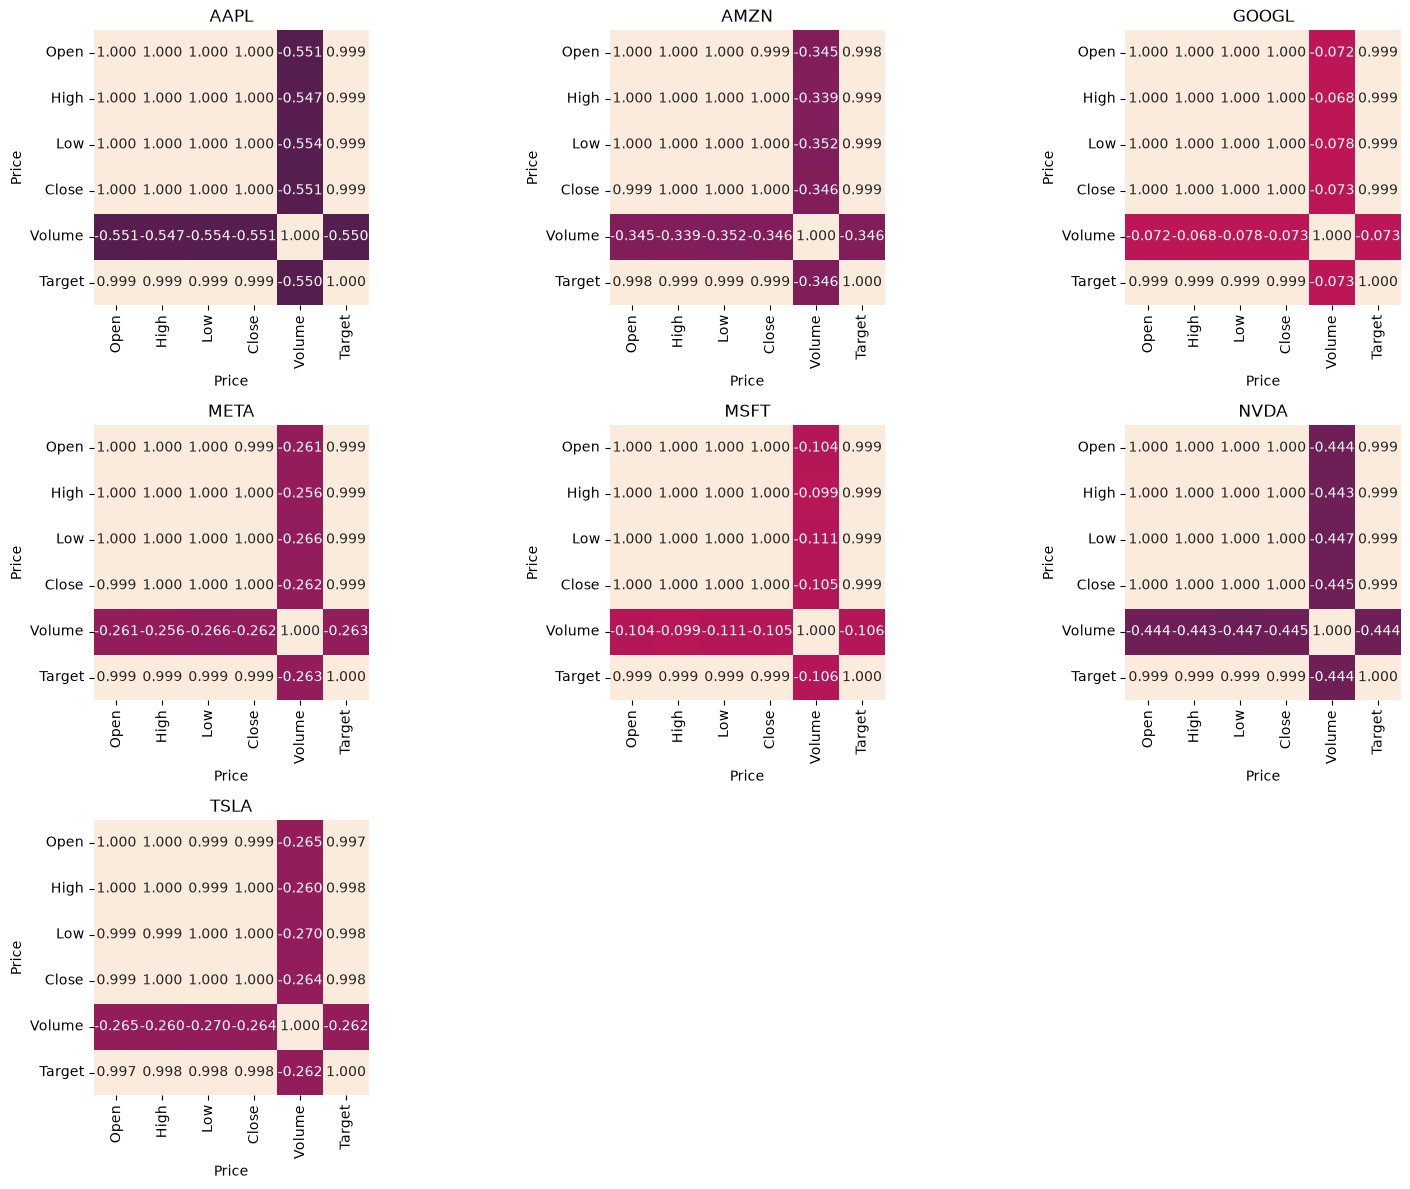

In [134]:
tickers = stock_df["Ticker"].unique()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    temp = stock_df[stock_df["Ticker"] == ticker].copy()
    
    cols = ["Open", "High", "Low", "Close", "Volume", "Target"]
    scaler = StandardScaler()
    temp[cols] = scaler.fit_transform(temp[cols])

    corr = temp[cols].corr()

    sns.heatmap(
        corr,
        annot=True,
        fmt=".3f",
        cmap="rocket",
        square=True,
        vmin=-1,
        vmax=1,
        cbar=False,
        ax=axes[i]
    )

    axes[i].set_title(ticker)

for j in range(len(tickers), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

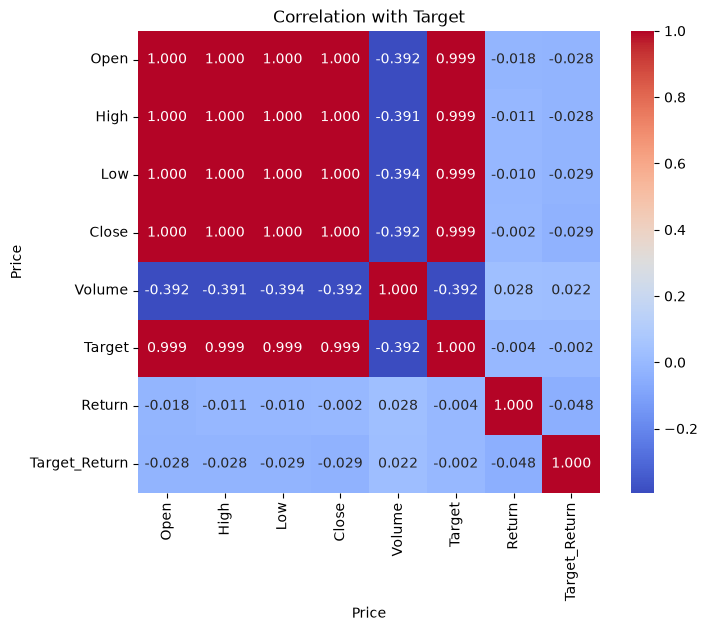

In [135]:
# Return: 전날 대비 변동률
# Target_Return: 다음날 변동률
temp_df = stock_df.copy()

temp_df["Return"] = (temp_df.groupby("Ticker")["Close"].pct_change())
temp_df["Target_Return"] = (temp_df.groupby("Ticker")["Return"].shift(-1))

corr = temp_df[[
    'Open',
    'High',
    'Low',
    'Close',
    'Volume',
    'Target',
    'Return',
    'Target_Return'
]].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    square=True
)

plt.title('Correlation with Target')
plt.show()

기존 히트맵(가격 변수): Open, High, Low, Close, Target은 모두 주가 수준을 나타내며 함께 움직이기 때문에 상관계수가 거의 1에 가깝게 나타남  
Return, Target_Return 히트맵: 수익률은 일별 변동률(Change)을 나타내며 하루의 상승·하락이 다음 날에도 이어지는 경향이 약해 상관계수가 0에 가깝게 나타남

In [136]:
stock_df = stock_df.dropna(subset=["Target"]).reset_index(drop=True)

X = stock_df.drop(columns=["Target"])
X = X.drop(columns=["Date"])

y = stock_df["Target"]

print(X.shape)
print(y.shape)

(17577, 6)
(17577,)


In [137]:
X_train_list = []
X_valid_list = []
X_test_list = []

y_train_list = []
y_valid_list = []
y_test_list = []

for ticker in X["Ticker"].unique():

    X_temp = X[X["Ticker"] == ticker]
    y_temp = y.loc[X_temp.index]

    train_end = int(len(X_temp) * 0.7)
    valid_end = train_end + int(len(X_temp) * 0.1)

    X_train_list.append(X_temp.iloc[:train_end])
    X_valid_list.append(X_temp.iloc[train_end:valid_end])
    X_test_list.append(X_temp.iloc[valid_end:])

    y_train_list.append(y_temp.iloc[:train_end])
    y_valid_list.append(y_temp.iloc[train_end:valid_end])
    y_test_list.append(y_temp.iloc[valid_end:])

X_train = pd.concat(X_train_list).reset_index(drop=True)
X_valid = pd.concat(X_valid_list).reset_index(drop=True)
X_test = pd.concat(X_test_list).reset_index(drop=True)

y_train = pd.concat(y_train_list).reset_index(drop=True)
y_valid = pd.concat(y_valid_list).reset_index(drop=True)
y_test = pd.concat(y_test_list).reset_index(drop=True)

print(f'X_train: {X_train.shape}, X_valid: {X_valid.shape}, X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}, y_valid: {y_valid.shape}, y_test: {y_test.shape}')

X_train: (12299, 6), X_valid: (1757, 6), X_test: (3521, 6)
y_train: (12299,), y_valid: (1757,), y_test: (3521,)


In [138]:
categorical_features = ["Ticker"]
numeric_features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

In [139]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            MinMaxScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [140]:
X_train = preprocessor.fit_transform(X_train)
X_valid = preprocessor.transform(X_valid)
X_test = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
feature_names

array(['num__Open', 'num__High', 'num__Low', 'num__Close', 'num__Volume',
       'cat__Ticker_AAPL', 'cat__Ticker_AMZN', 'cat__Ticker_GOOGL',
       'cat__Ticker_META', 'cat__Ticker_MSFT', 'cat__Ticker_NVDA',
       'cat__Ticker_TSLA'], dtype=object)

In [141]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=SEED),
    "Random Forest": RandomForestRegressor(
        random_state=SEED
    ),
    "XGBoost": XGBRegressor(
        random_state=SEED
    ),
    "LightGBM": LGBMRegressor(
        random_state=SEED,
        verbose=-1
    ),
    "SVR": SVR()
}

In [142]:
def evaluate_model(model, model_name, X_train, y_train, X_test, y_test, feature_names):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "feature_importances_"):
        importance = model.feature_importances_

        feature_importance = pd.DataFrame({
            "Feature": feature_names,
            "Importance": importance
        }).sort_values(
            "Importance",
            ascending=False
        )

        print(f"\n{model_name} Feature Importance")
        print(feature_importance.head(10))

    elif hasattr(model, "coef_"):
        importance = np.abs(model.coef_)

        feature_importance = pd.DataFrame({
            "Feature": feature_names,
            "Importance": importance
        }).sort_values(
            "Importance",
            ascending=False
        )

        print(f"\n{model_name} Feature Importance")
        print(feature_importance.head(10))

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": mape,
        "R2 Score": r2,
        "y_pred": y_pred
    }

In [143]:
results = []

for model_name, model in models.items():

    result = evaluate_model(
        model,
        model_name,
        X_train,
        y_train,
        X_valid,
        y_valid,
        feature_names
    )

    results.append(result)

result_df = (
    pd.DataFrame(results)
    .sort_values("R2 Score", ascending=False)
    .reset_index(drop=True)
)


Linear Regression Feature Importance
              Feature  Importance
3          num__Close  302.887078
2            num__Low   98.058264
1           num__High   70.602823
0           num__Open   63.147884
4         num__Volume    0.291572
10   cat__Ticker_NVDA    0.175097
11   cat__Ticker_TSLA    0.154127
9    cat__Ticker_MSFT    0.103072
7   cat__Ticker_GOOGL    0.080476
8    cat__Ticker_META    0.070118

Ridge Regression Feature Importance
              Feature  Importance
3          num__Close  144.705273
2            num__Low  105.177969
1           num__High   97.428592
0           num__Open   61.058935
10   cat__Ticker_NVDA    0.263024
8    cat__Ticker_META    0.195858
9    cat__Ticker_MSFT    0.192404
7   cat__Ticker_GOOGL    0.111295
11   cat__Ticker_TSLA    0.085614
6    cat__Ticker_AMZN    0.070316



Random Forest Feature Importance
             Feature  Importance
3         num__Close    0.759677
1          num__High    0.114658
2           num__Low    0.112251
0          num__Open    0.013023
4        num__Volume    0.000319
11  cat__Ticker_TSLA    0.000022
8   cat__Ticker_META    0.000020
9   cat__Ticker_MSFT    0.000015
6   cat__Ticker_AMZN    0.000008
5   cat__Ticker_AAPL    0.000004

XGBoost Feature Importance
             Feature  Importance
3         num__Close    0.876381
1          num__High    0.082837
2           num__Low    0.039300
0          num__Open    0.000384
8   cat__Ticker_META    0.000292
4        num__Volume    0.000241
11  cat__Ticker_TSLA    0.000191
9   cat__Ticker_MSFT    0.000148
5   cat__Ticker_AAPL    0.000097
6   cat__Ticker_AMZN    0.000091

LightGBM Feature Importance
              Feature  Importance
4         num__Volume         974
3          num__Close         683
2            num__Low         460
1           num__High         400
0           n

In [144]:
result_df.drop('y_pred', axis=1)

,Model,MAE,MSE,RMSE,MAPE,R2 Score
0,Linear Regression,3.038569,24.699530,4.969862,0.014858,0.998206
1,Ridge Regression,3.180437,26.691927,5.166423,0.015563,0.998061
2,Random Forest,8.781666,490.231258,22.141167,0.028044,0.964388
3,LightGBM,11.645174,872.323825,29.535129,0.034085,0.936631
4,XGBoost,12.177416,887.223691,29.786300,0.036660,0.935549
5,SVR,28.473797,3969.868499,63.006892,0.087718,0.711614


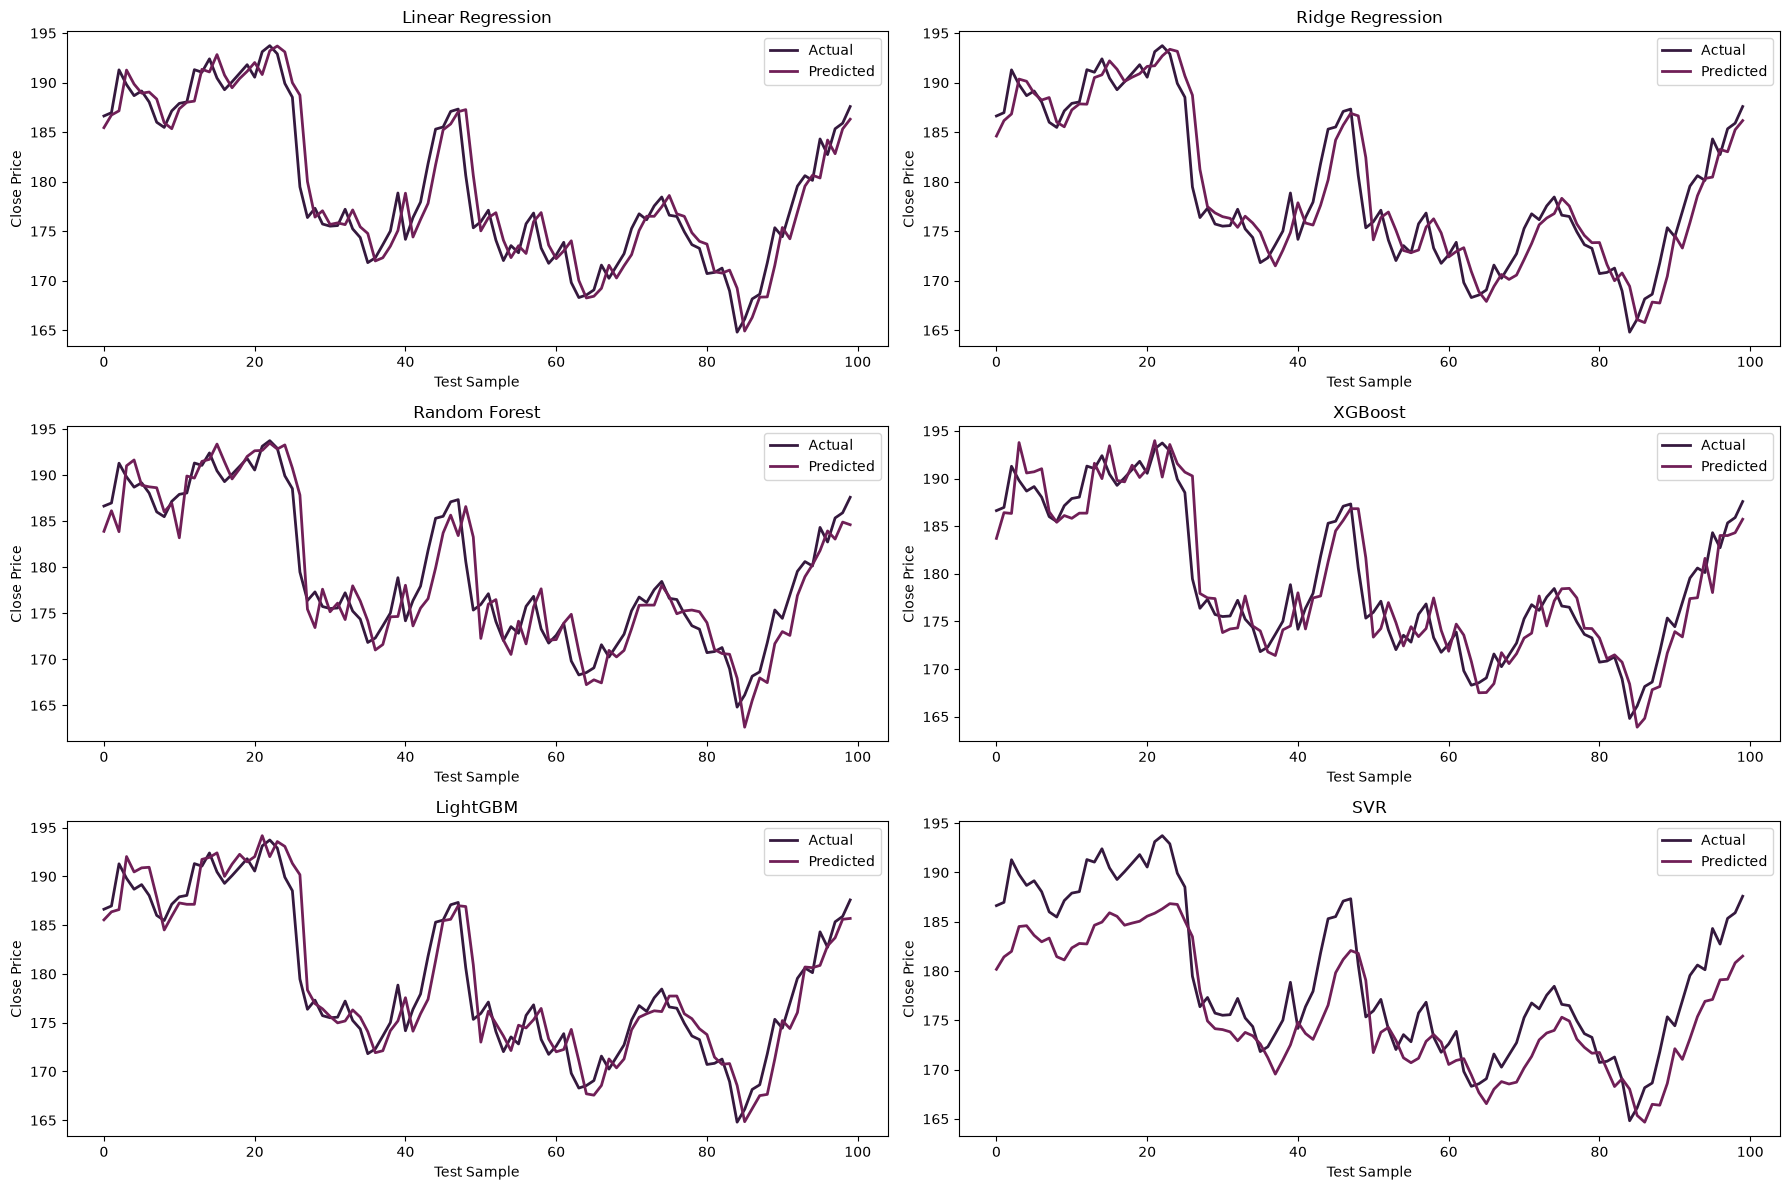

In [145]:
start = 0
end = 100

fig, axes = plt.subplots(3, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, result in zip(axes, results):

    ax.plot(
        y_valid.iloc[start:end].values,
        label="Actual",
        linewidth=2
    )

    ax.plot(
        result["y_pred"][start:end],
        label="Predicted",
        linewidth=2
    )

    ax.set_title(result["Model"])
    ax.set_xlabel("Test Sample")
    ax.set_ylabel("Close Price")
    ax.legend()

plt.tight_layout()
plt.show()

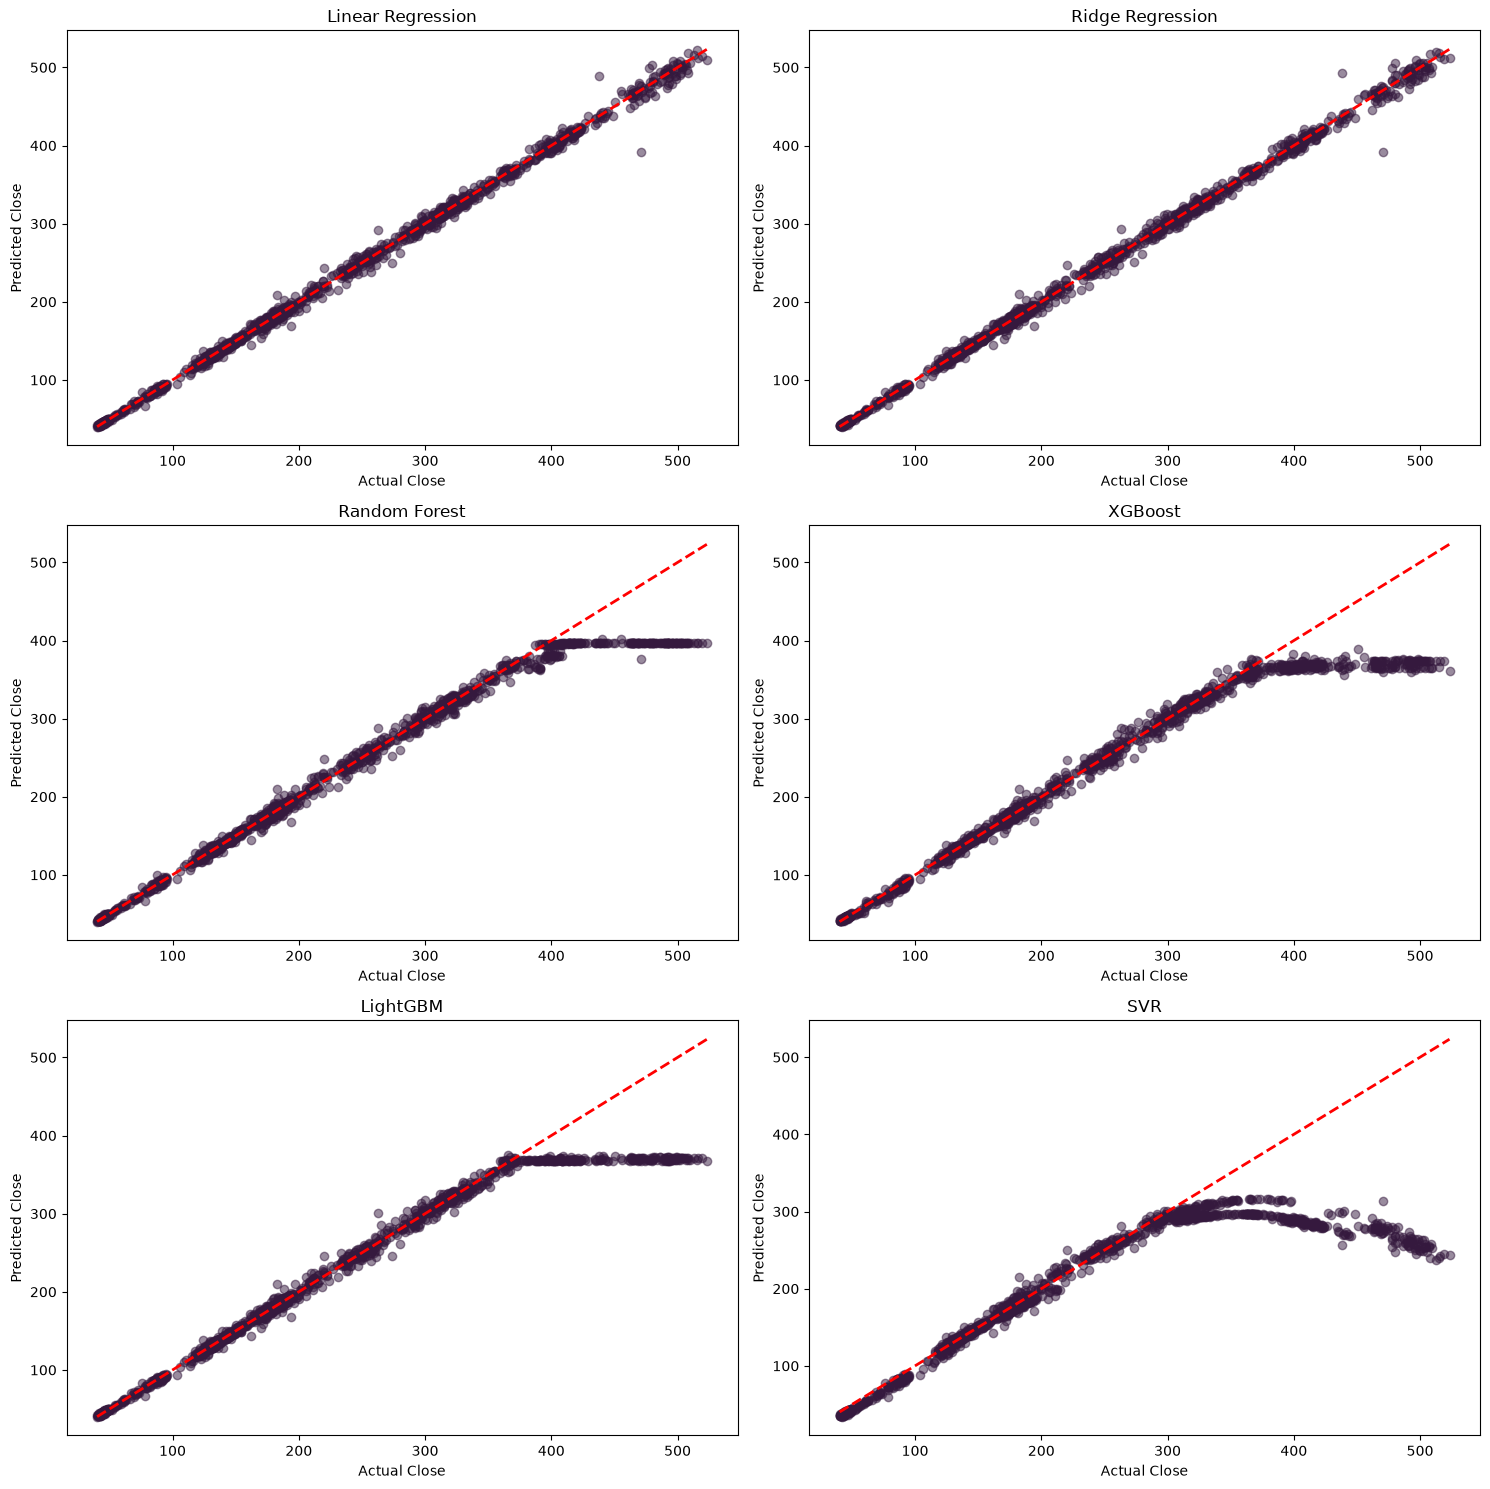

In [146]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

for ax, result in zip(axes, results):

    ax.scatter(
        y_valid,
        result["y_pred"],
        alpha=0.5
    )

    ax.plot(
        [y_valid.min(), y_valid.max()],
        [y_valid.min(), y_valid.max()],
        "r--",
        linewidth=2
    )

    ax.set_title(result["Model"])
    ax.set_xlabel("Actual Close")
    ax.set_ylabel("Predicted Close")

plt.tight_layout()
plt.show()

선형 기반 회귀 모델은 선형을 따라 예측하는 모습  
트리 기반 모델은 학습한 값 이상을 예측하지 못하는 모습  
SVR은 평균값으로 예측하려는 모습

## Feature Engineering

| Feature | 설명 | 계산 방법 | 의미 |
|---------|------|----------|------|
| **MA5** | 5일 이동평균선 | 최근 5일 종가의 평균 | 단기 가격 추세를 나타내며 단기 매매에 자주 사용된다. |
| **MA20** | 20일 이동평균선 | 최근 20일 종가의 평균 | 약 1개월간의 평균 가격으로 중기 추세를 파악하는 데 사용된다. |
| **MA60** | 60일 이동평균선 | 최근 60일 종가의 평균 | 장기 가격 추세를 나타내며 추세 전환 여부를 판단하는 데 활용된다. |
| **Lag1 (1 day ago Close)** | 1일 전 종가 | 전 거래일 종가 | 가장 최근의 종가 정보를 이용하여 다음 날 가격을 예측한다. |
| **Lag3 (3 days ago Close)** | 3일 전 종가 | 3거래일 전 종가 | 단기 가격 흐름을 반영하기 위한 시계열 특성이다. |
| **Lag5 (5 days ago Close)** | 5일 전 종가 | 5거래일 전 종가 | 약 1주일 전 가격 정보를 반영하여 추세를 학습한다. |
| **Return** | 일간 수익률 | 현재 종가와 이전 거래일 종가의 변화율 | 주가의 단기 상승·하락 정도를 나타내며, 가격 방향성과 모멘텀 정보를 제공한다. |
| **Volatility** | 변동성 | 일정 기간(예: 20일) 수익률의 표준편차 | 값이 클수록 가격 변동이 심하며 위험도가 높은 종목으로 볼 수 있다. |
| **Bollinger Upper** | 볼린저 밴드 상단 | MA20 + 2 × 표준편차 | 가격이 상단에 가까울수록 과매수 가능성을 의미한다. |
| **Bollinger Lower** | 볼린저 밴드 하단 | MA20 − 2 × 표준편차 | 가격이 하단에 가까울수록 과매도 가능성을 의미한다. |
| **Bollinger Width** | 볼린저 밴드 폭 | Upper − Lower | 밴드 폭이 넓을수록 변동성이 크고, 좁을수록 변동성이 작은 상태를 의미한다. |
| **RSI** | Relative Strength Index (상대강도지수) | 최근 상승폭과 하락폭을 이용하여 0~100 사이의 값 계산 | 일반적으로 70 이상은 과매수, 30 이하는 과매도로 해석한다. |

In [147]:
fe_df = stock_df.copy()

In [148]:
# ==========================
# Moving Average
# ==========================
fe_df["MA5"] = (
    fe_df.groupby("Ticker")["Close"]
            .transform(lambda x: x.rolling(5).mean())
)
fe_df["MA20"] = (
    fe_df.groupby("Ticker")["Close"]
            .transform(lambda x: x.rolling(20).mean())
)
fe_df["MA60"] = (
    fe_df.groupby("Ticker")["Close"]
            .transform(lambda x: x.rolling(60).mean())
)

# ==========================
# Lag Features
# ==========================
fe_df["Lag1"] = (
    fe_df.groupby("Ticker")["Close"].shift(1)
)
fe_df["Lag3"] = (
    fe_df.groupby("Ticker")["Close"].shift(3)
)
fe_df["Lag5"] = (
    fe_df.groupby("Ticker")["Close"].shift(5)
)

# ==========================
# Daily Return
# ==========================
fe_df["Return"] = (
    fe_df.groupby("Ticker")["Close"]
            .pct_change()
)

# ==========================
# Volatility (20일)
# ==========================
fe_df["Volatility"] = (
    fe_df.groupby("Ticker")["Return"]
            .transform(lambda x: x.rolling(20).std())
)

# ==========================
# Bollinger Band (20일)
# ==========================
rolling_mean = (
    fe_df.groupby("Ticker")["Close"]
            .transform(lambda x: x.rolling(20).mean())
)
rolling_std = (
    fe_df.groupby("Ticker")["Close"]
            .transform(lambda x: x.rolling(20).std())
)

fe_df["Bollinger Upper"] = rolling_mean + 2 * rolling_std
fe_df["Bollinger Lower"] = rolling_mean - 2 * rolling_std
fe_df["Bollinger Width"] = (
    fe_df["Bollinger Upper"] -
    fe_df["Bollinger Lower"]
)

# ==========================
# RSI (14일)
# ==========================
delta = (fe_df.groupby("Ticker")["Close"].diff())

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = (
    gain.groupby(fe_df["Ticker"])
        .transform(lambda x: x.rolling(14).mean())
)
avg_loss = (
    loss.groupby(fe_df["Ticker"])
        .transform(lambda x: x.rolling(14).mean())
)

rs = avg_gain / avg_loss
fe_df["RSI"] = 100 - (100 / (1 + rs))

fe_df.head(10)

Price,Date,Ticker,Open,High,Low,Close,Volume,Target,MA5,MA20,MA60,Lag1,Lag3,Lag5,Return,Volatility,Bollinger Upper,Bollinger Lower,Bollinger Width,RSI
0,2016-07-01,AAPL,21.738265,21.961362,21.701841,21.829325,104106000,21.624437,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-07-05,AAPL,21.715498,21.717775,21.503783,21.624437,110820800,21.747372,NaN,NaN,NaN,21.829325,NaN,NaN,-0.009386,NaN,NaN,NaN,NaN,NaN
2,2016-07-06,AAPL,21.535657,21.776967,21.483299,21.747372,123796400,21.840704,NaN,NaN,NaN,21.624437,NaN,NaN,0.005685,NaN,NaN,NaN,NaN,NaN
3,2016-07-07,AAPL,21.786067,21.968187,21.767856,21.840704,100558400,22.009167,NaN,NaN,NaN,21.747372,21.829325,NaN,0.004292,NaN,NaN,NaN,NaN,NaN
4,2016-07-08,AAPL,21.965913,22.056973,21.865748,22.009167,115648400,22.077463,21.810201,NaN,NaN,21.840704,21.624437,NaN,0.007713,NaN,NaN,NaN,NaN,NaN
5,2016-07-11,AAPL,22.025103,22.229988,22.020551,22.077463,95179600,22.177629,21.859829,NaN,NaN,22.009167,21.747372,21.829325,0.003103,NaN,NaN,NaN,NaN,NaN
6,2016-07-12,AAPL,22.120717,22.241371,22.109336,22.177629,96670000,22.052422,21.970467,NaN,NaN,22.077463,21.840704,21.624437,0.004537,NaN,NaN,NaN,NaN,NaN
7,2016-07-13,AAPL,22.175353,22.234540,22.045591,22.052422,103568800,22.489513,22.031477,NaN,NaN,22.177629,22.009167,21.747372,-0.005646,NaN,NaN,NaN,NaN,NaN
8,2016-07-14,AAPL,22.170803,22.535043,22.154868,22.489513,155676000,22.487234,22.161239,NaN,NaN,22.052422,22.077463,21.840704,0.019821,NaN,NaN,NaN,NaN,NaN
9,2016-07-15,AAPL,22.519105,22.605613,22.423492,22.487234,120548000,22.726267,22.256852,NaN,NaN,22.489513,22.177629,22.009167,-0.000101,NaN,NaN,NaN,NaN,NaN


In [149]:
fe_df.isna().sum()

Price
Date                 0
Ticker               0
Open                 0
High                 0
Low                  0
Close                0
Volume               0
Target               0
MA5                 28
MA20               133
MA60               413
Lag1                 7
Lag3                21
Lag5                35
Return               7
Volatility         140
Bollinger Upper    133
Bollinger Lower    133
Bollinger Width    133
RSI                 98
dtype: int64

In [150]:
fe_df = fe_df.dropna().reset_index(drop=True)
fe_df.isna().sum()

Price
Date               0
Ticker             0
Open               0
High               0
Low                0
Close              0
Volume             0
Target             0
MA5                0
MA20               0
MA60               0
Lag1               0
Lag3               0
Lag5               0
Return             0
Volatility         0
Bollinger Upper    0
Bollinger Lower    0
Bollinger Width    0
RSI                0
dtype: int64

In [151]:
fe_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17164 entries, 0 to 17163
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype        
---  ------           --------------  -----        
 0   Date             17164 non-null  datetime64[s]
 1   Ticker           17164 non-null  str          
 2   Open             17164 non-null  float64      
 3   High             17164 non-null  float64      
 4   Low              17164 non-null  float64      
 5   Close            17164 non-null  float64      
 6   Volume           17164 non-null  int64        
 7   Target           17164 non-null  float64      
 8   MA5              17164 non-null  float64      
 9   MA20             17164 non-null  float64      
 10  MA60             17164 non-null  float64      
 11  Lag1             17164 non-null  float64      
 12  Lag3             17164 non-null  float64      
 13  Lag5             17164 non-null  float64      
 14  Return           17164 non-null  float64      
 15  Volatility   

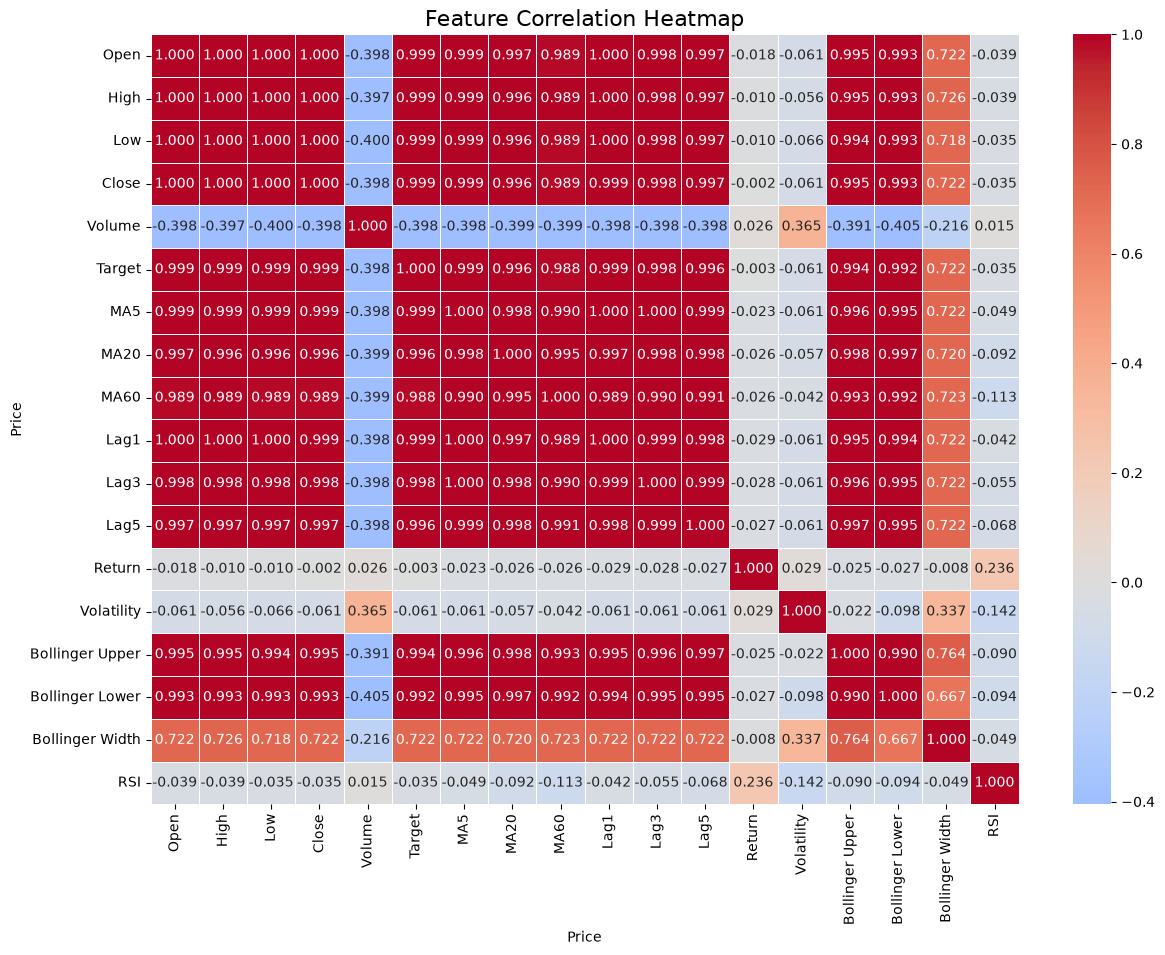

In [152]:
corr_df = fe_df.select_dtypes(include=["int64", "float64"])

corr_matrix = corr_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=16)
plt.show()

In [153]:
fe_df = fe_df.dropna(subset=["Target"]).reset_index(drop=True)

X = fe_df.drop(columns=["Target", "Date"])
y = fe_df["Target"]

print(X.shape)
print(y.shape)

(17164, 18)
(17164,)


In [154]:
X_train_list = []
X_valid_list = []
X_test_list = []

y_train_list = []
y_valid_list = []
y_test_list = []


for ticker in X["Ticker"].unique():

    X_temp = X[X["Ticker"] == ticker]
    y_temp = y.loc[X_temp.index]

    train_end = int(len(X_temp) * 0.7)
    valid_end = train_end + int(len(X_temp) * 0.1)

    X_train_list.append(X_temp.iloc[:train_end])
    X_valid_list.append(X_temp.iloc[train_end:valid_end])
    X_test_list.append(X_temp.iloc[valid_end:])

    y_train_list.append(y_temp.iloc[:train_end])
    y_valid_list.append(y_temp.iloc[train_end:valid_end])
    y_test_list.append(y_temp.iloc[valid_end:])


X_train = pd.concat(X_train_list).reset_index(drop=True)
X_valid = pd.concat(X_valid_list).reset_index(drop=True)
X_test = pd.concat(X_test_list).reset_index(drop=True)

y_train = pd.concat(y_train_list).reset_index(drop=True)
y_valid = pd.concat(y_valid_list).reset_index(drop=True)
y_test = pd.concat(y_test_list).reset_index(drop=True)

print(f"X_train: {X_train.shape}, X_valid: {X_valid.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_valid: {y_valid.shape}, y_test: {y_test.shape}")

X_train: (12012, 18), X_valid: (1715, 18), X_test: (3437, 18)
y_train: (12012,), y_valid: (1715,), y_test: (3437,)


In [155]:
categorical_features = [
    "Ticker"
]

numeric_features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "MA5",
    "MA20",
    "MA60",
    "Lag1",
    "Lag3",
    "Lag5",
    "Return",
    "Volatility",
    "Bollinger Upper",
    "Bollinger Lower",
    "Bollinger Width",
    "RSI"
]

In [156]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            MinMaxScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [157]:
X_train = preprocessor.fit_transform(X_train)
X_valid = preprocessor.transform(X_valid)
X_test = preprocessor.transform(X_test)

print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

feature_names = preprocessor.get_feature_names_out()
feature_names

(12012, 24)
(1715, 24)
(3437, 24)


array(['num__Open', 'num__High', 'num__Low', 'num__Close', 'num__Volume',
       'num__MA5', 'num__MA20', 'num__MA60', 'num__Lag1', 'num__Lag3',
       'num__Lag5', 'num__Return', 'num__Volatility',
       'num__Bollinger Upper', 'num__Bollinger Lower',
       'num__Bollinger Width', 'num__RSI', 'cat__Ticker_AAPL',
       'cat__Ticker_AMZN', 'cat__Ticker_GOOGL', 'cat__Ticker_META',
       'cat__Ticker_MSFT', 'cat__Ticker_NVDA', 'cat__Ticker_TSLA'],
      dtype=object)

In [158]:
fe_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=SEED),
    "Random Forest": RandomForestRegressor(
        random_state=SEED
    ),
    "XGBoost": XGBRegressor(
        random_state=SEED
    ),
    "LightGBM": LGBMRegressor(
        random_state=SEED,
        verbose=-1
    ),
    "SVR": SVR()
}

In [159]:
fe_results = []

for model_name, model in fe_models.items():
    result = evaluate_model(
        model,
        model_name,
        X_train,
        y_train,
        X_valid,
        y_valid,
        feature_names
    )
    fe_results.append(result)

fe_result_df = pd.DataFrame(fe_results).sort_values(
        "R2 Score", ascending=False
    ).reset_index(drop=True)

fe_result_df.drop('y_pred', axis=1)


Linear Regression Feature Importance
                 Feature  Importance
3             num__Close  318.250120
2               num__Low  103.187323
0              num__Open   67.943313
1              num__High   58.208590
5               num__MA5   40.371560
9              num__Lag3   23.406030
8              num__Lag1    9.268185
10             num__Lag5    8.307623
14  num__Bollinger Lower    1.702337
6              num__MA20    1.464696

Ridge Regression Feature Importance
                 Feature  Importance
3             num__Close  111.342006
2               num__Low   84.158216
1              num__High   72.031461
8              num__Lag1   44.136469
0              num__Open   43.439284
5               num__MA5   36.829171
11           num__Return   19.054821
9              num__Lag3    8.254671
6              num__MA20    2.163311
14  num__Bollinger Lower    2.132471

Random Forest Feature Importance
                 Feature  Importance
3             num__Close    0.815160
2  

,Model,MAE,MSE,RMSE,MAPE,R2 Score
0,Linear Regression,3.137248,26.221789,5.120722,0.015052,0.998181
1,Ridge Regression,3.261088,27.981116,5.289718,0.015601,0.998059
2,Random Forest,13.092327,1046.842136,32.354940,0.037014,0.927364
3,LightGBM,13.276109,1072.137371,32.743509,0.037364,0.925609
4,XGBoost,14.010250,1142.212326,33.796632,0.039923,0.920747
5,SVR,34.070429,6224.724553,78.896924,0.090920,0.568093


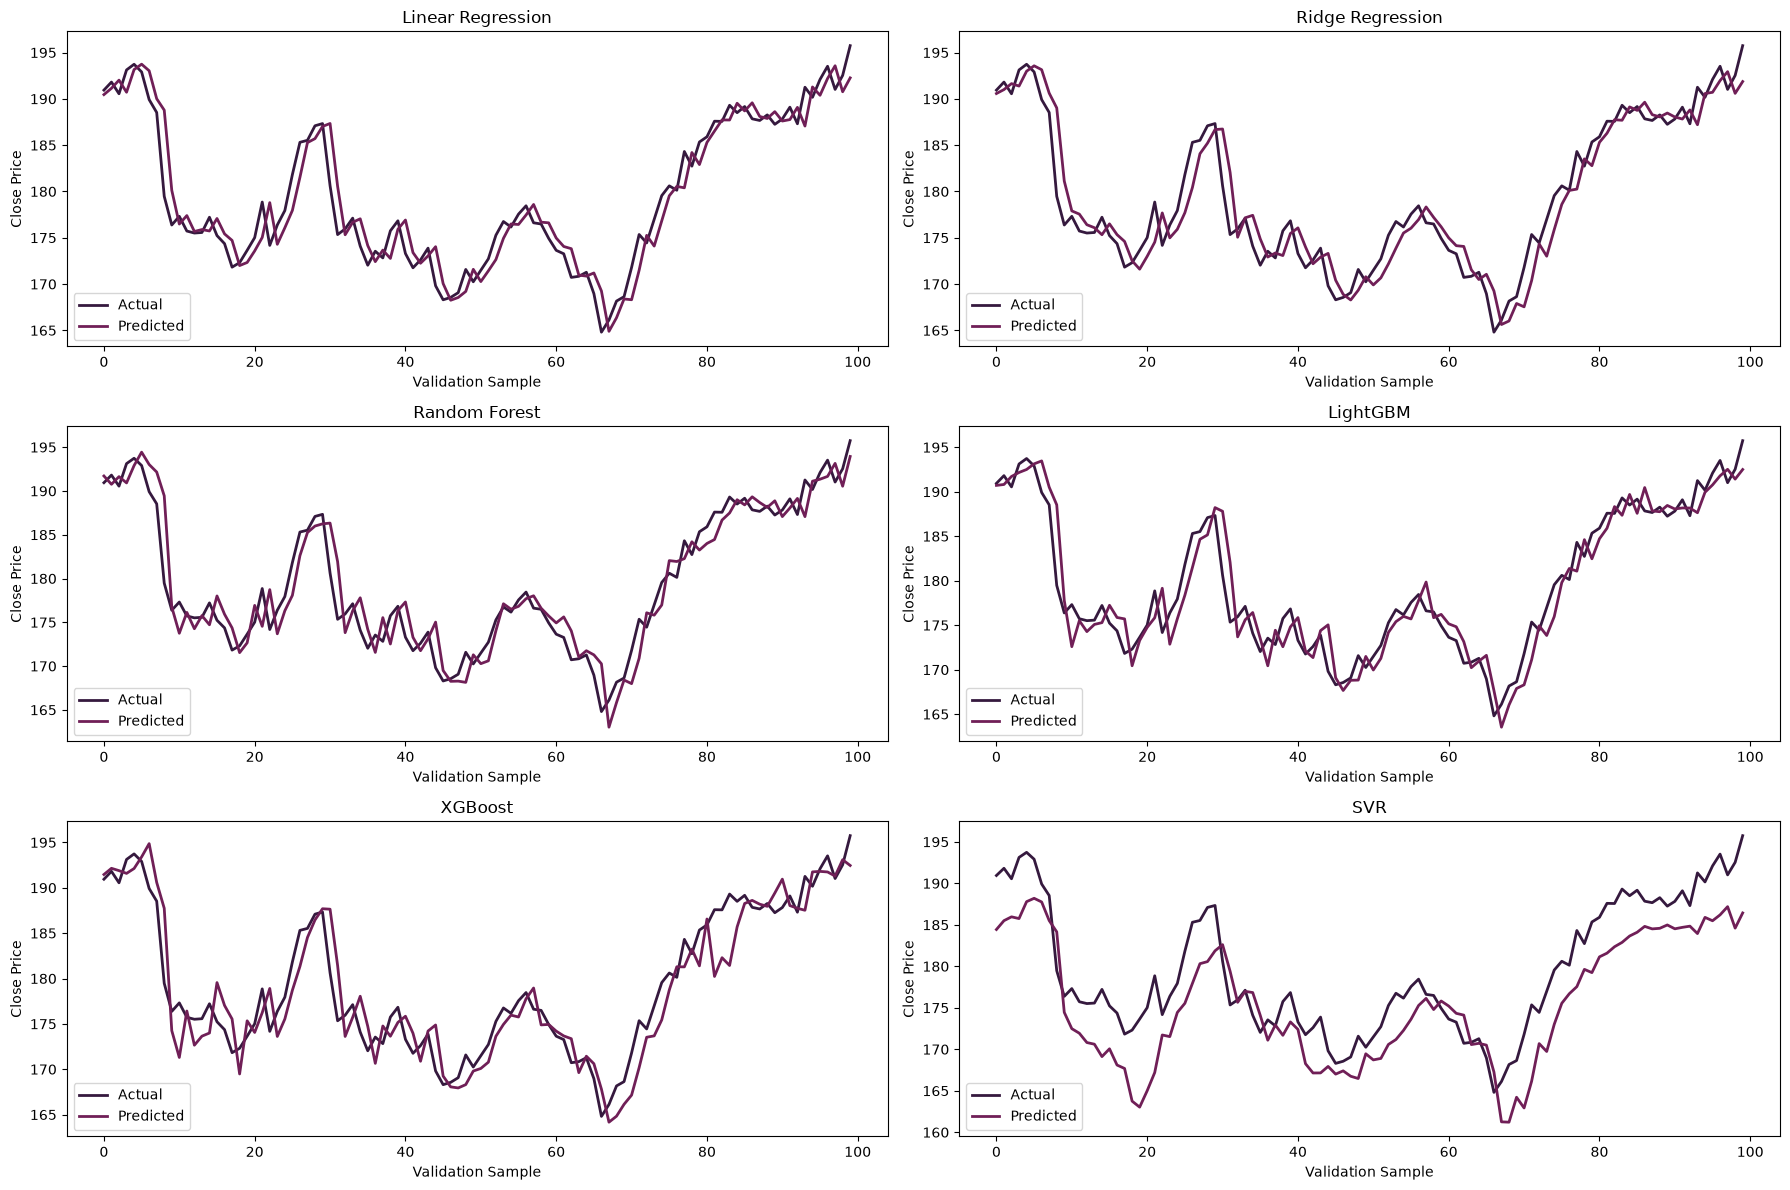

In [160]:
start = 0
end = 100

fig, axes = plt.subplots(3, 2, figsize=(18, 12))

axes = axes.flatten()

for ax, (_, result) in zip(axes, fe_result_df.iterrows()):
    ax.plot(
        y_valid.iloc[start:end].values,
        label="Actual",
        linewidth=2
    )
    ax.plot(
        result["y_pred"][start:end],
        label="Predicted",
        linewidth=2
    )

    ax.set_title(result["Model"])
    ax.set_xlabel("Validation Sample")
    ax.set_ylabel("Close Price")
    ax.legend()


plt.tight_layout()
plt.show()

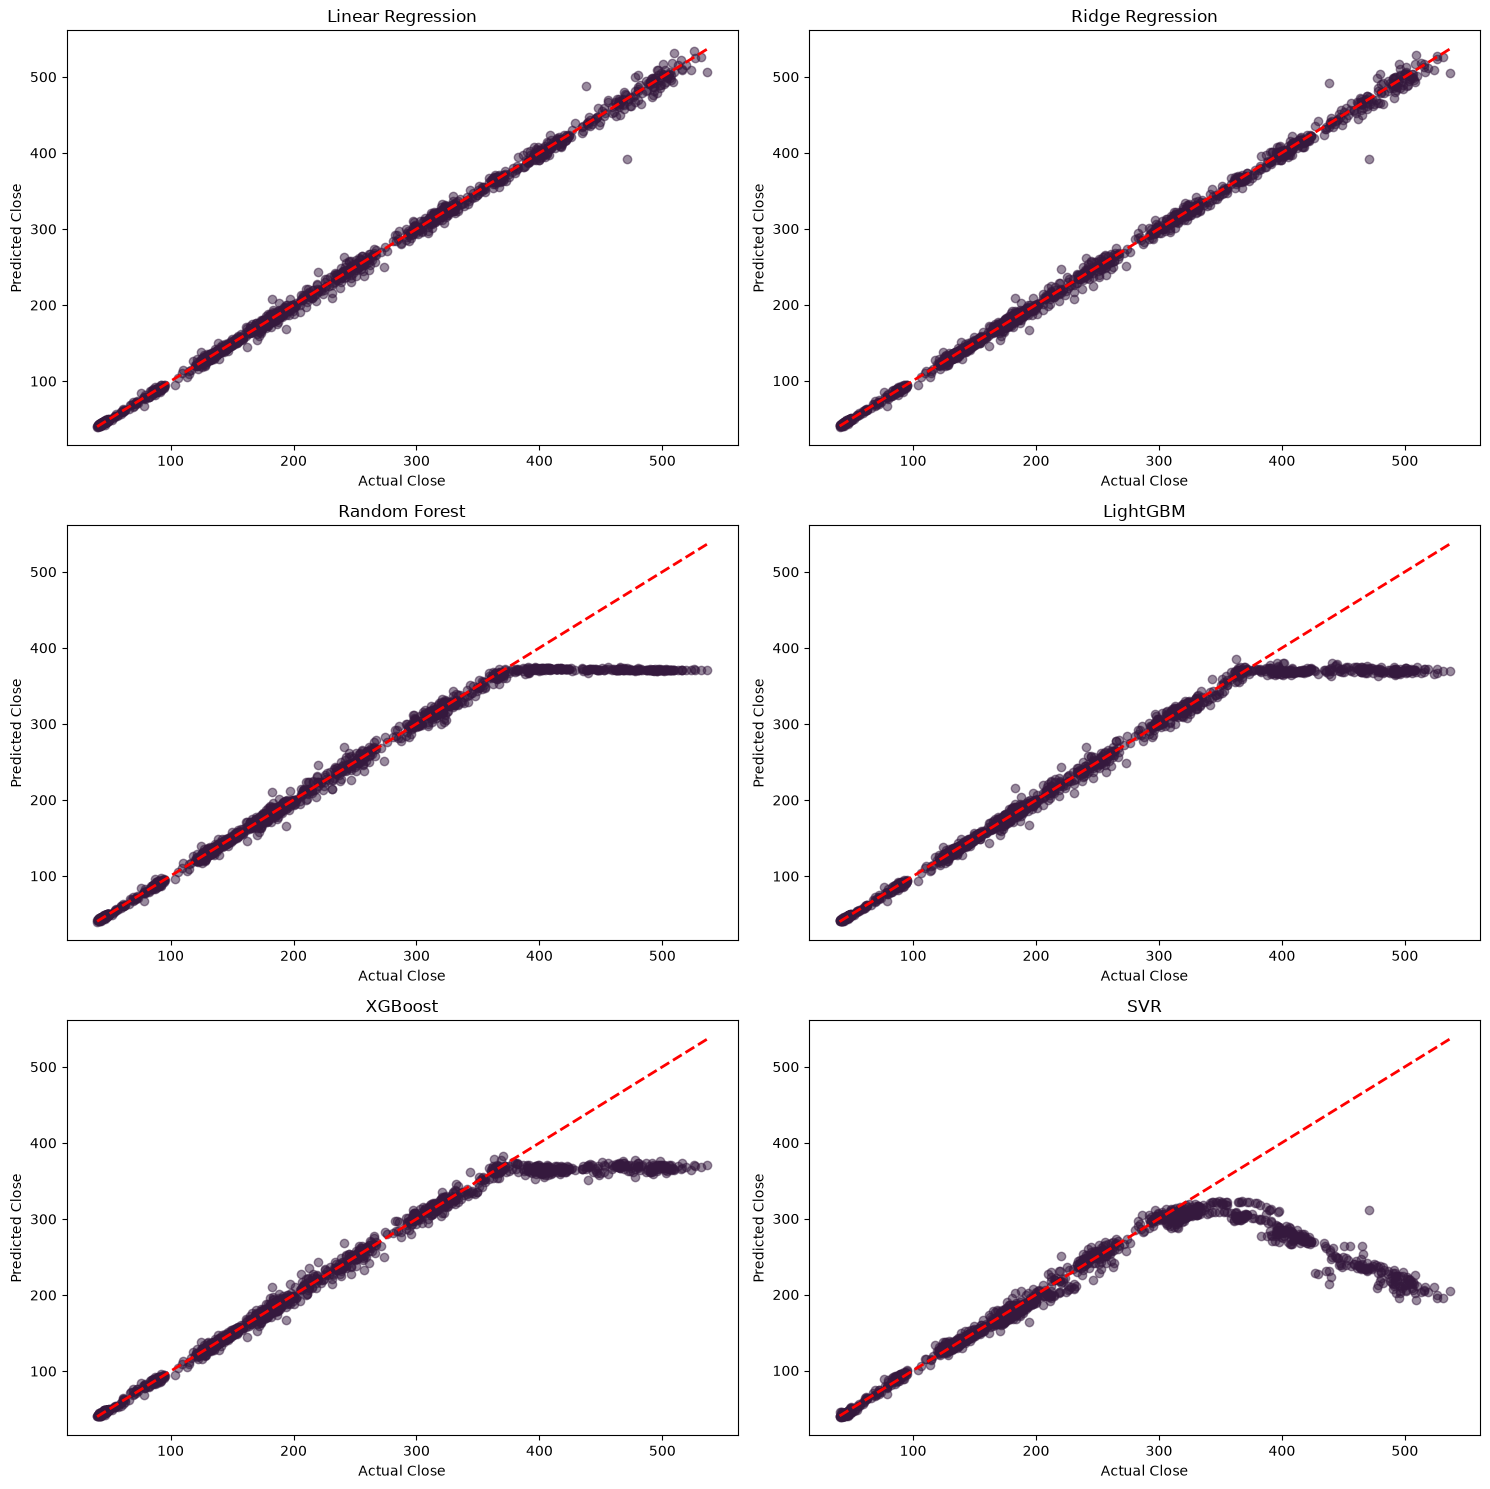

In [161]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

axes = axes.flatten()

for ax, (_, result) in zip(axes, fe_result_df.iterrows()):
    ax.scatter(
        y_valid,
        result["y_pred"],
        alpha=0.5
    )

    ax.plot(
        [y_valid.min(), y_valid.max()],
        [y_valid.min(), y_valid.max()],
        "r--",
        linewidth=2
    )

    ax.set_title(result["Model"])
    ax.set_xlabel("Actual Close")
    ax.set_ylabel("Predicted Close")

plt.tight_layout()
plt.show()

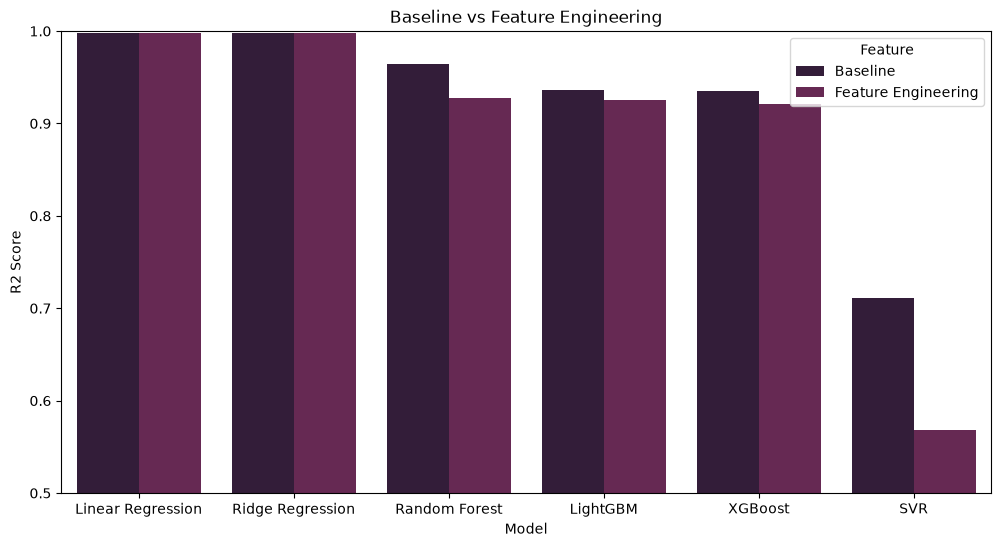

In [162]:
compare_df = pd.concat(
    [
        result_df.assign(Feature="Baseline"),
        fe_result_df.assign(Feature="Feature Engineering")
    ],
    ignore_index=True
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=compare_df,
    x="Model",
    y="R2 Score",
    hue="Feature"
)

plt.xticks(rotation=0)
plt.ylim(0.5, 1)
plt.title("Baseline vs Feature Engineering")
plt.show()

In [163]:
def objective_ridge(trial):
    params = {"alpha": trial.suggest_float("alpha", 0.001, 100, log=True)}

    model = Ridge(**params, random_state=SEED)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)

    return np.sqrt(mean_squared_error(y_valid, pred))


def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    }

    model = RandomForestRegressor(
        **params,
        random_state=SEED,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)

    return np.sqrt(mean_squared_error(y_valid, pred))


def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "num_leaves": trial.suggest_int("num_leaves", 10, 200),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5)
    }

    model = LGBMRegressor(
        **params,
        random_state=SEED,
        verbose=-1
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_valid)

    return np.sqrt(mean_squared_error(y_valid, pred))

In [164]:
objectives = {
    "Ridge": objective_ridge,
    "Random Forest": objective_rf,
    "LightGBM": objective_lgbm
}

studies = {}

for name, objective in objectives.items():
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=100, show_progress_bar=True)
    studies[name] = study

    print(name)
    print("Best RMSE:", study.best_value)
    print("Best Params:", study.best_params)
    print("-"*50)

Best trial: 31. Best value: 5.12061: 100%|██████████| 100/100 [00:00<00:00, 128.84it/s]


Ridge
Best RMSE: 5.120611643754719
Best Params: {'alpha': 0.0035788245292226227}
--------------------------------------------------


Best trial: 79. Best value: 30.1131: 100%|██████████| 100/100 [06:01<00:00,  3.62s/it]


Random Forest
Best RMSE: 30.113138513937642
Best Params: {'n_estimators': 124, 'max_depth': 9, 'min_samples_split': 16, 'min_samples_leaf': 3, 'max_features': None}
--------------------------------------------------


Best trial: 77. Best value: 32.362: 100%|██████████| 100/100 [01:45<00:00,  1.05s/it]

LightGBM
Best RMSE: 32.36197789181865
Best Params: {'n_estimators': 521, 'learning_rate': 0.21776760243060989, 'max_depth': 4, 'num_leaves': 99, 'subsample': 0.6451691504264163, 'colsample_bytree': 0.5170208521361064, 'reg_alpha': 4.451833941324845, 'reg_lambda': 1.737773521610885}
--------------------------------------------------


In [165]:
optuna_results = []

best_models = {
    "Ridge": Ridge(**studies["Ridge"].best_params, random_state=SEED),
    "Random Forest": RandomForestRegressor(**studies["Random Forest"].best_params, random_state=SEED, n_jobs=-1),
    "LightGBM": LGBMRegressor(**studies["LightGBM"].best_params, random_state=SEED, verbose=-1)
}

for name, model in best_models.items():
    result = evaluate_model(
        model,
        name + " Optuna",
        X_train,
        y_train,
        X_valid,
        y_valid,
        feature_names
    )
    optuna_results.append(result)

optuna_result_df = pd.DataFrame(optuna_results).sort_values(
    "R2 Score",
    ascending=False
).reset_index(drop=True)

optuna_result_df


Ridge Optuna Feature Importance
                 Feature  Importance
3             num__Close  310.381971
2               num__Low  105.197053
0              num__Open   67.230844
1              num__High   60.850255
5               num__MA5   31.122597
9              num__Lag3   19.710502
10             num__Lag5    7.403013
8              num__Lag1    6.994308
14  num__Bollinger Lower    1.713025
6              num__MA20    1.476379

Random Forest Optuna Feature Importance
                 Feature  Importance
3             num__Close    0.821163
2               num__Low    0.095185
1              num__High    0.066102
0              num__Open    0.006977
8              num__Lag1    0.005456
5               num__MA5    0.004603
7              num__MA60    0.000063
12       num__Volatility    0.000062
14  num__Bollinger Lower    0.000061
15  num__Bollinger Width    0.000051

LightGBM Optuna Feature Importance
                 Feature  Importance
11           num__Return         567
4 

,Model,MAE,MSE,RMSE,MAPE,R2 Score,y_pred
0,Ridge Optuna,3.137185,26.220664,5.120612,0.015050,0.998181,"[190.46333294712088, 191.14478726290832, 192.0..."
1,Random Forest Optuna,12.079941,906.801111,30.113139,0.034522,0.937081,"[191.9106577856024, 190.9777213634188, 191.245..."
2,LightGBM Optuna,13.417445,1047.297613,32.361978,0.038353,0.927332,"[194.78676385766204, 193.82410157270652, 193.7..."


In [166]:
os.makedirs("models/optuna_models", exist_ok=True)

def save_models(model_dict, save_dir):
    for name, model in model_dict.items():
        filename = f"{name.lower().replace(' ', '_')}.joblib"
        path = os.path.join(save_dir, filename)

        joblib.dump(model, path)
        print(f"Saved: {path}")

save_models(best_models, "models/optuna_models")

Saved: models/optuna_models\ridge.joblib
Saved: models/optuna_models\random_forest.joblib
Saved: models/optuna_models\lightgbm.joblib


In [167]:
all_result_df = pd.concat(
    [
        result_df.assign(Version="Baseline"),
        fe_result_df.assign(Version="Feature Engineering"),
        optuna_result_df.assign(Version="Optuna")
    ],
    ignore_index=True
)

all_result_df

,Model,MAE,MSE,RMSE,MAPE,R2 Score,y_pred,Version
0,Linear Regression,3.038569,24.699530,4.969862,0.014858,0.998206,"[185.4555177252676, 186.73115227413143, 187.15...",Baseline
1,Ridge Regression,3.180437,26.691927,5.166423,0.015563,0.998061,"[184.60508878769133, 186.1657258464669, 186.83...",Baseline
2,Random Forest,8.781666,490.231258,22.141167,0.028044,0.964388,"[183.89180130004883, 186.12582550048828, 183.8...",Baseline
3,LightGBM,11.645174,872.323825,29.535129,0.034085,0.936631,"[185.54547399022582, 186.36709854420067, 186.5...",Baseline
4,XGBoost,12.177416,887.223691,29.786300,0.036660,0.935549,"[183.71591, 186.41785, 186.3371, 193.78027, 19...",Baseline
5,SVR,28.473797,3969.868499,63.006892,0.087718,0.711614,"[180.17347266957995, 181.43143819934681, 181.9...",Baseline
6,Linear Regression,3.137248,26.221789,5.120722,0.015052,0.998181,"[190.45747991468733, 191.1416542502613, 192.01...",Feature Engineering
7,Ridge Regression,3.261088,27.981116,5.289718,0.015601,0.998059,"[190.57436016065878, 191.00146012726637, 191.6...",Feature Engineering
8,Random Forest,13.092327,1046.842136,32.354940,0.037014,0.927364,"[191.70959701538087, 190.7614596557617, 191.63...",Feature Engineering
9,LightGBM,13.276109,1072.137371,32.743509,0.037364,0.925609,"[190.71610226235694, 190.81763819120633, 191.7...",Feature Engineering


In [168]:
all_result_df.drop('y_pred', axis=1).to_csv(
    "dataset/model_comparison_results.csv",
    index=False
)

In [169]:
def load_models(load_dir):
    loaded = {}

    for file in os.listdir(load_dir):
        if file.endswith(".joblib"):
            name = file.replace(".joblib", "")
            loaded[name] = joblib.load(os.path.join(load_dir, file))

    return loaded

In [170]:
optuna_loaded = load_models("models/optuna_models")

optuna_test_results = []

for name, model in optuna_loaded.items():
    y_pred = model.predict(X_test)

    optuna_test_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAPE": mean_absolute_percentage_error(y_test, y_pred),
        "R2 Score": r2_score(y_test, y_pred),
        "y_pred": y_pred
    })

optuna_test_result_df = pd.DataFrame(optuna_test_results).sort_values(
    "R2 Score", ascending=False
).reset_index(drop=True)

optuna_test_result_df.drop("y_pred", axis=1)

,Model,MAE,MSE,RMSE,MAPE,R2 Score
0,ridge,5.277242,69.205390,8.318978,0.017003,0.997351
1,random_forest,50.136159,10743.911631,103.652842,0.093315,0.588766
2,lightgbm,52.857639,11228.251437,105.963444,0.099801,0.570227


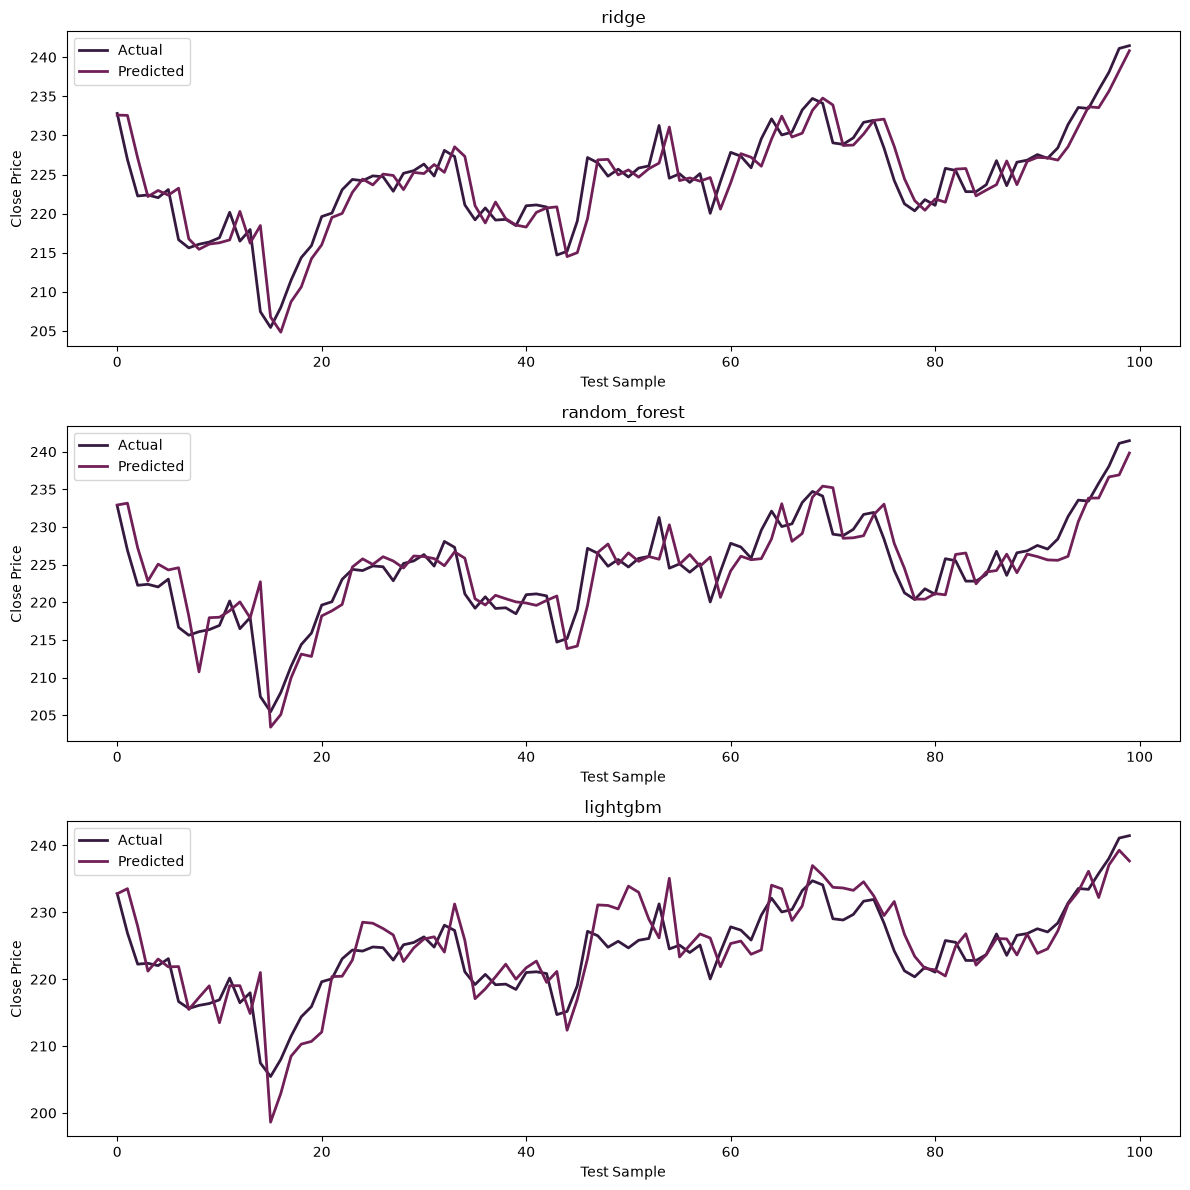

In [171]:
start = 0
end = 100

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for ax, result in zip(axes, optuna_test_result_df.itertuples()):
    ax.plot(
        y_test.iloc[start:end].values,
        label="Actual",
        linewidth=2
    )

    ax.plot(
        result.y_pred[start:end],
        label="Predicted",
        linewidth=2
    )

    ax.set_title(result.Model)
    ax.set_xlabel("Test Sample")
    ax.set_ylabel("Close Price")
    ax.legend()

plt.tight_layout()
plt.show()

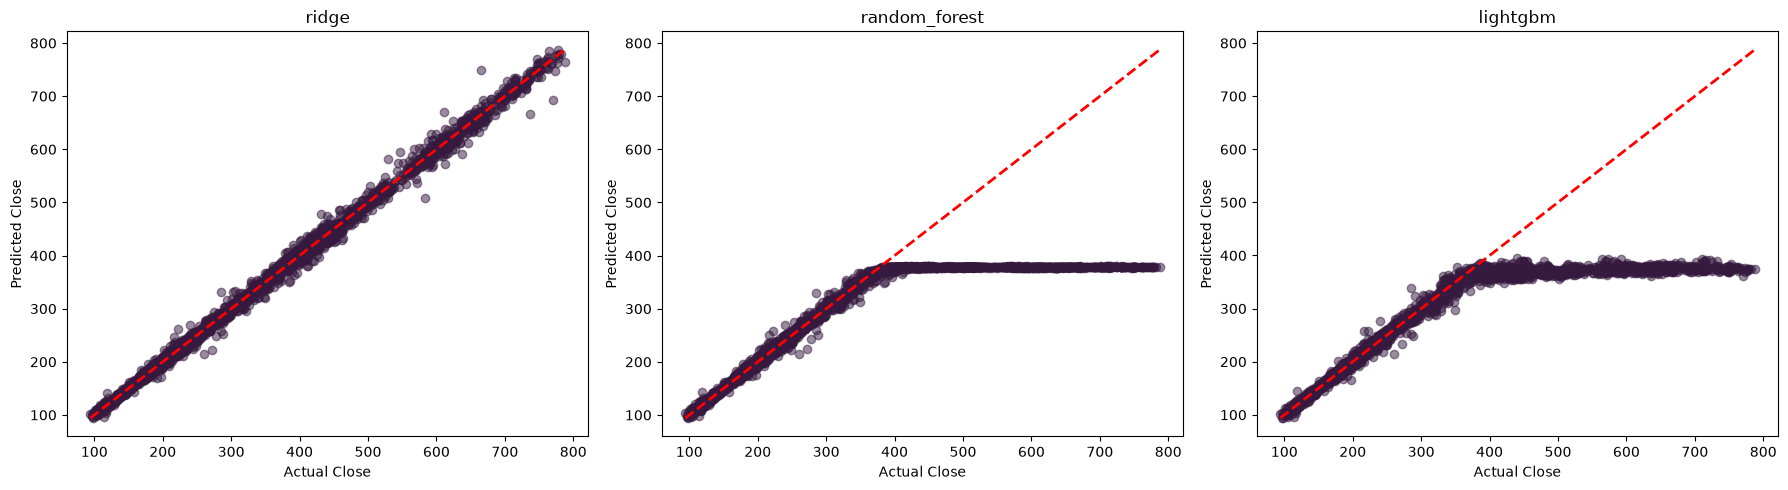

In [172]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, result in zip(axes, optuna_test_result_df.itertuples()):
    ax.scatter(
        y_test,
        result.y_pred,
        alpha=0.5
    )

    ax.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        "r--",
        linewidth=2
    )

    ax.set_title(result.Model)
    ax.set_xlabel("Actual Close")
    ax.set_ylabel("Predicted Close")

plt.tight_layout()
plt.show()

In [175]:
fe_test_results = []

for model_name, model in fe_models.items():
    y_pred = model.predict(X_test)

    fe_test_results.append({
        "Model": model_name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAPE": mean_absolute_percentage_error(y_test, y_pred),
        "R2 Score": r2_score(y_test, y_pred),
        "y_pred": y_pred
    })

fe_test_result_df = pd.DataFrame(fe_test_results).sort_values(
    "R2 Score", ascending=False
).reset_index(drop=True)

fe_test_result_df.drop("y_pred", axis=1)

,Model,MAE,MSE,RMSE,MAPE,R2 Score
0,Linear Regression,5.276028,69.228407,8.320361,0.016999,0.997350
1,Ridge Regression,5.579348,75.271935,8.675940,0.017817,0.997119
2,Random Forest,52.684182,11461.212913,107.057054,0.098635,0.561311
3,LightGBM,53.222264,11508.905437,107.279567,0.099846,0.559485
4,XGBoost,55.098039,11910.541196,109.135426,0.104408,0.544112
5,SVR,119.494014,42043.256183,205.044522,0.245580,-0.609248


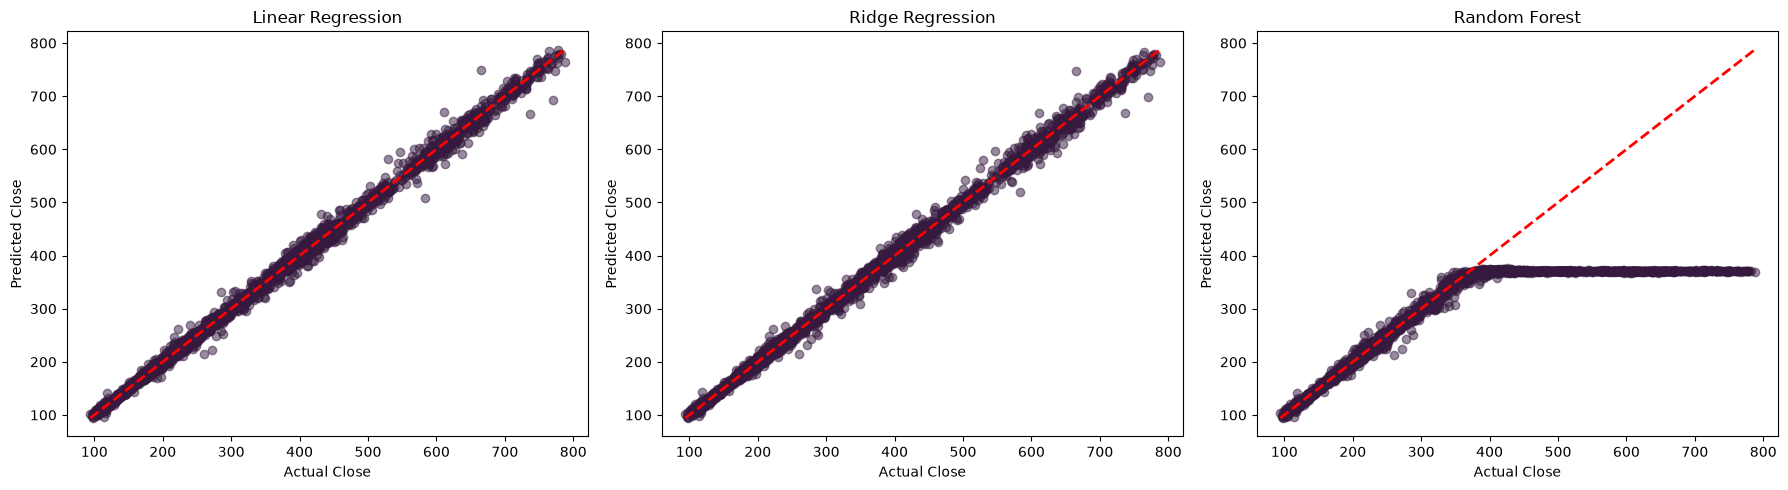

In [185]:
target_models = [
    "Linear Regression",
    "Random Forest",
    "LightGBM"
]

plot_df = fe_test_result_df[
    fe_test_result_df["Model"].isin(target_models)
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, result in zip(axes, fe_test_result_df.itertuples()):
    ax.scatter(
        y_test,
        result.y_pred,
        alpha=0.5
    )

    ax.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        "r--",
        linewidth=2
    )

    ax.set_title(result.Model)
    ax.set_xlabel("Actual Close")
    ax.set_ylabel("Predicted Close")

plt.tight_layout()
plt.show()